# Explainable AI-Based Phishing URL Detection






In [3]:
# ============================================================
# Cell 1: Imports and Global Configuration
# ============================================================

import sys, os, json, time, math, re, warnings, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

matplotlib.rcParams.update({
    'font.size'        : 14,
    'axes.titlesize'   : 15,
    'axes.labelsize'   : 14,
    'xtick.labelsize'  : 12,
    'ytick.labelsize'  : 12,
    'legend.fontsize'  : 12,
    'figure.dpi'       : 150,
    'savefig.dpi'      : 300,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dataset paths
PRIMARY_DATASET_PATH  = "/PhiUSIIL_Phishing_URL_Dataset.csv"
EXTERNAL_DATASET_PATH = "/url_features_extracted1.csv"

#  Output directories
OUTPUT_DIR = Path("outputs")
for sub in ['figures', 'tables', 'models', 'explanations']:
    (OUTPUT_DIR / sub).mkdir(parents=True, exist_ok=True)

# Optional packages
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("WARNING: xgboost not found -- install: pip install xgboost")

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("WARNING: shap not found -- install: pip install shap")

try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False
    print("WARNING: lime not found -- install: pip install lime")

import joblib
import sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
)
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline

# Reproducibility snapshot
print("=" * 62)
print("REPRODUCIBILITY SNAPSHOT")
print("=" * 62)
print(f"Python       : {sys.version.split()[0]}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"xgboost      : {xgb.__version__ if XGB_AVAILABLE else 'NOT INSTALLED'}")
if SHAP_AVAILABLE:
    print(f"shap         : {shap.__version__}")
else:
    print("shap         : NOT INSTALLED")
if LIME_AVAILABLE:
    import lime; print(f"lime         : {lime.__version__}")
else:
    print("lime         : NOT INSTALLED")
print(f"joblib       : {joblib.__version__}")
print(f"platform     : {platform.platform()}")
print(f"Random seed  : {RANDOM_STATE}")
print(f"Primary data : {PRIMARY_DATASET_PATH}")
print(f"Ext data     : {EXTERNAL_DATASET_PATH}")
print(f"Output dir   : {OUTPUT_DIR.resolve()}")
print("=" * 62)


REPRODUCIBILITY SNAPSHOT
Python       : 3.12.13
pandas       : 2.2.2
numpy        : 2.0.2
scikit-learn : 1.6.1
xgboost      : 3.2.0
shap         : 0.52.0
lime         : NOT INSTALLED
joblib       : 1.5.3
platform     : Linux-6.6.122+-x86_64-with-glibc2.35
Random seed  : 42
Primary data : /PhiUSIIL_Phishing_URL_Dataset.csv
Ext data     : /url_features_extracted1.csv
Output dir   : /content/outputs


In [4]:
# ============================================================
# Cell 2: Utility Functions
# ============================================================

from urllib.parse import urlparse

# Column detection
LABEL_CANDIDATES = [
    'label','Label','class','Class','status','Status',
    'type','Type','phishing','is_phishing','isPhishing',
    'target','Target','result','Result',
]
URL_CANDIDATES = [
    'URL','url','WebsiteURL','website','Website',
    'link','Link','domain','Domain','address','Address',
]

def _detect_col(df, candidates, kind):
    for c in candidates:
        if c in df.columns:
            return c
    pattern = ('label|class|phish|target|status' if kind == 'label'
                else 'url|link|website|domain')
    for c in df.columns:
        if re.search(pattern, c, re.I):
            return c
    return None

def detect_label_col(df):
    col = _detect_col(df, LABEL_CANDIDATES, 'label')
    if col is None:
        raise ValueError(
            "Could not auto-detect label column.\n"
            "Set LABEL_COLUMN manually at the top of Cell 3."
        )
    return col

def detect_url_col(df):
    return _detect_col(df, URL_CANDIDATES, 'url')

#  Label binarisation
PHISHING_TOKENS = {'1','phishing','malicious','bad','spam',
                   'fake','suspicious','1.0','phish'}

def binarize(series):
    def _map(v):
        sv = str(v).strip().lower()
        if sv in PHISHING_TOKENS:
            return 1
        try:
            return 1 if float(sv) == 1.0 else 0
        except ValueError:
            return 0
    return series.map(_map).astype(int)

#  Domain extraction
def extract_domain(url):
    try:
        p = urlparse(str(url).strip())
        netloc = p.netloc or p.path.split('/')[0]
        return netloc.lower().lstrip('www.')
    except Exception:
        return ''

#  Shannon entropy
def entropy(s):
    s = str(s)
    if not s:
        return 0.0
    cnt = {}
    for c in s:
        cnt[c] = cnt.get(c, 0) + 1
    n = len(s)
    return -sum((v/n) * math.log2(v/n) for v in cnt.values())

# URL-only lexical feature extraction
IP_RE   = re.compile(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}')
SUS_TLD = {'.xyz','.top','.club','.online','.site',
           '.tk','.ml','.ga','.cf','.gq'}
KW_LIST = ['login','verify','update','secure','account','bank',
           'paypal','wallet','invoice','password','signin','confirm']

def url_features(url):
    url = str(url).strip()
    try:
        p = urlparse(url if '://' in url else 'http://' + url)
    except Exception:
        p = urlparse('')
    host  = p.hostname or ''
    path  = p.path     or ''
    query = p.query    or ''
    low   = url.lower()
    d = {
        'url_length'               : len(url),
        'hostname_length'          : len(host),
        'path_length'              : len(path),
        'query_length'             : len(query),
        'num_dots'                 : url.count('.'),
        'num_hyphens'              : url.count('-'),
        'num_digits'               : sum(c.isdigit() for c in url),
        'num_special_chars'        : sum(c in '!@#$%^&*()+=[]{}|;<>,?' for c in url),
        'num_slashes'              : url.count('/'),
        'num_subdomains'           : max(0, host.count('.') - 1),
        'has_ip_address'           : int(bool(IP_RE.search(host))),
        'has_https'                : int(url.startswith('https')),
        'has_at_symbol'            : int('@' in url),
        'has_double_slash_redirect': int('//' in path),
        'entropy'                  : round(entropy(url), 4),
    }
    for kw in KW_LIST:
        d[f'count_{kw}'] = low.count(kw)
    return d

def url_feature_df(series):
    return pd.DataFrame([url_features(u) for u in series])

#  Model evaluation
def evaluate(model, X_test, y_test, name, model_type='Main Model'):
    y_pred  = model.predict(X_test)
    y_proba = (model.predict_proba(X_test)[:, 1]
               if hasattr(model, 'predict_proba')
               else y_pred.astype(float))
    cm       = confusion_matrix(y_test, y_pred)
    tn,fp,fn,tp = cm.ravel()
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)
    fpr_ = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr_ = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    return {
        'Model Type' : model_type, 'Model': name,
        'Accuracy'   : round(acc,  6), 'Precision': round(prec, 6),
        'Recall'     : round(rec,  6), 'F1'       : round(f1,   6),
        'ROC_AUC'    : round(auc,  6),
        'FP': int(fp), 'FN': int(fn), 'TP': int(tp), 'TN': int(tn),
        'FPR': round(fpr_, 6), 'FNR': round(fnr_, 6),
        'CM': cm, 'y_proba': y_proba, 'y_pred': y_pred,
    }

#  Save figure helper
def save_fig(fig, stem):
    base = str(OUTPUT_DIR / 'figures' / stem)
    fig.savefig(base + '.png', dpi=300, bbox_inches='tight')
    try:
        fig.savefig(base + '.pdf', bbox_inches='tight')
    except Exception:
        pass
    print(f"  Saved {stem}.png / .pdf")

print("Utilities loaded.")


Utilities loaded.


In [ ]:
# ============================================================
# Cell 3: Load and Inspect the Primary Dataset (PhiUSIIL)
# ============================================================

print("Loading primary dataset ...")
df_raw = pd.read_csv(PRIMARY_DATASET_PATH)
print(f"  Raw shape : {df_raw.shape}")
print(f"  All columns ({df_raw.shape[1]}):")
for i, c in enumerate(df_raw.columns):
    print(f"    [{i:>3}] {c}")

LABEL_COL = detect_label_col(df_raw)
URL_COL   = detect_url_col(df_raw)
print(f"\n  Detected label column : '{LABEL_COL}'")
if URL_COL:
    print(f"  Detected URL column   : '{URL_COL}'")
else:
    print("  URL column            : NOT FOUND -- URL checks will be skipped.")

# Remove duplicate rows
n_before   = len(df_raw)
df_clean   = df_raw.drop_duplicates().reset_index(drop=True)
n_dup_rows = n_before - len(df_clean)
print(f"\n  Duplicate rows removed : {n_dup_rows:,}")

# Remove duplicate URLs
n_dup_urls = 0
if URL_COL:
    n_b      = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=[URL_COL]).reset_index(drop=True)
    n_dup_urls = n_b - len(df_clean)
    print(f"  Duplicate URLs removed : {n_dup_urls:,}")

# Binarise labels
df_clean['_label'] = binarize(df_clean[LABEL_COL])
dist = df_clean['_label'].value_counts().rename({0:'Legitimate', 1:'Phishing'})
print(f"\n  Clean shape : {df_clean.shape}")
print("  Class distribution:")
print(dist.to_string())
dist.to_frame('Count').to_csv(OUTPUT_DIR/'tables'/'class_dist_primary.csv')


Loading primary dataset ...
  Raw shape : (235795, 56)
  All columns (56):
    [  0] FILENAME
    [  1] URL
    [  2] URLLength
    [  3] Domain
    [  4] DomainLength
    [  5] IsDomainIP
    [  6] TLD
    [  7] URLSimilarityIndex
    [  8] CharContinuationRate
    [  9] TLDLegitimateProb
    [ 10] URLCharProb
    [ 11] TLDLength
    [ 12] NoOfSubDomain
    [ 13] HasObfuscation
    [ 14] NoOfObfuscatedChar
    [ 15] ObfuscationRatio
    [ 16] NoOfLettersInURL
    [ 17] LetterRatioInURL
    [ 18] NoOfDegitsInURL
    [ 19] DegitRatioInURL
    [ 20] NoOfEqualsInURL
    [ 21] NoOfQMarkInURL
    [ 22] NoOfAmpersandInURL
    [ 23] NoOfOtherSpecialCharsInURL
    [ 24] SpacialCharRatioInURL
    [ 25] IsHTTPS
    [ 26] LineOfCode
    [ 27] LargestLineLength
    [ 28] HasTitle
    [ 29] Title
    [ 30] DomainTitleMatchScore
    [ 31] URLTitleMatchScore
    [ 32] HasFavicon
    [ 33] Robots
    [ 34] IsResponsive
    [ 35] NoOfURLRedirect
    [ 36] NoOfSelfRedirect
    [ 37] HasDescription
    [

In [ ]:
# ============================================================
# Cell 4: Load and Inspect the External Dataset
# ============================================================

EXT_AVAILABLE  = False
df_ext         = None
LABEL_COL_EXT  = None
URL_COL_EXT    = None

if not os.path.exists(EXTERNAL_DATASET_PATH):
    print(f"WARNING: External dataset not found at: {EXTERNAL_DATASET_PATH}")
    print("  Experiment 2 (URL-only generalization) will be skipped.")
else:
    print("Loading external dataset ...")
    df_ext_raw  = pd.read_csv(EXTERNAL_DATASET_PATH)
    print(f"  Raw shape : {df_ext_raw.shape}")
    print(f"  All columns ({df_ext_raw.shape[1]}):")
    for i, c in enumerate(df_ext_raw.columns):
        print(f"    [{i:>3}] {c}")

    LABEL_COL_EXT = detect_label_col(df_ext_raw)
    URL_COL_EXT   = detect_url_col(df_ext_raw)
    print(f"\n  Detected label column : '{LABEL_COL_EXT}'")
    if URL_COL_EXT:
        print(f"  Detected URL column   : '{URL_COL_EXT}'")
    else:
        print("  URL column            : NOT FOUND")

    df_ext = df_ext_raw.drop_duplicates().reset_index(drop=True)
    df_ext['_label'] = binarize(df_ext[LABEL_COL_EXT])

    dist_ext = df_ext['_label'].value_counts().rename({0:'Legitimate', 1:'Phishing'})
    print(f"\n  Clean shape : {df_ext.shape}")
    print("  Class distribution:")
    print(dist_ext.to_string())
    dist_ext.to_frame('Count').to_csv(OUTPUT_DIR/'tables'/'class_dist_external.csv')
    EXT_AVAILABLE = True


Loading external dataset ...
  Raw shape : (101219, 18)
  All columns (18):
    [  0] URL
    [  1] url_length
    [  2] has_ip_address
    [  3] dot_count
    [  4] https_flag
    [  5] url_entropy
    [  6] token_count
    [  7] subdomain_count
    [  8] query_param_count
    [  9] tld_length
    [ 10] path_length
    [ 11] has_hyphen_in_domain
    [ 12] number_of_digits
    [ 13] tld_popularity
    [ 14] suspicious_file_extension
    [ 15] domain_name_length
    [ 16] percentage_numeric_chars
    [ 17] ClassLabel

  Detected label column : 'ClassLabel'
  Detected URL column   : 'URL'

  Clean shape : (100873, 19)
  Class distribution:
_label
Legitimate    63493
Phishing      37380


In [ ]:
# ============================================================
# Cell 5: Balanced Subset, Feature Selection, Train/Test Split
# ============================================================
# Paper setup: 60,000 phishing + 60,000 legitimate = 120,000 total
# ============================================================

TARGET_PER_CLASS = 60_000

phish_df = df_clean[df_clean['_label'] == 1]
legit_df = df_clean[df_clean['_label'] == 0]
n_each   = min(TARGET_PER_CLASS, len(phish_df), len(legit_df))

if n_each < TARGET_PER_CLASS:
    print(f"WARNING: Cannot reach {TARGET_PER_CLASS:,}/class. "
          f"Using max balanced sample: {n_each:,}/class ({2*n_each:,} total).")
else:
    print(f"Building balanced subset: {n_each:,} phishing + {n_each:,} legitimate "
          f"= {2*n_each:,} total (matches paper setup).")

df_phish = phish_df.sample(n=n_each, random_state=RANDOM_STATE)
df_legit = legit_df.sample(n=n_each, random_state=RANDOM_STATE)
df_work  = (pd.concat([df_phish, df_legit])
              .sample(frac=1, random_state=RANDOM_STATE)
              .reset_index(drop=True))
print(f"  Working subset shape : {df_work.shape}")

# Select numeric engineered features
EXCLUDE = {'_label', LABEL_COL}
if URL_COL:
    EXCLUDE.add(URL_COL)
for col in df_work.columns:
    if df_work[col].dtype == object:
        EXCLUDE.add(col)

FEATURE_COLS = [c for c in df_work.select_dtypes(include=[np.number]).columns
                if c not in EXCLUDE]
print(f"\n  Full-feature set : {len(FEATURE_COLS)} features")
print(f"  First 10         : {FEATURE_COLS[:10]}")

X_full = df_work[FEATURE_COLS].fillna(0)
y_full = df_work['_label']

# Stratified 80/20 split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_full, y_full,
    test_size=0.20, random_state=RANDOM_STATE, stratify=y_full,
)
TRAIN_IDX = X_tr.index
TEST_IDX  = X_te.index
print(f"\n  Train : {len(X_tr):,}  |  Test : {len(X_te):,}")
print(f"  Train class dist : {dict(y_tr.value_counts())}")
print(f"  Test  class dist : {dict(y_te.value_counts())}")


Building balanced subset: 60,000 phishing + 60,000 legitimate = 120,000 total (matches paper setup).
  Working subset shape : (120000, 57)

  Full-feature set : 50 features
  First 10         : ['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation']

  Train : 96,000  |  Test : 24,000
  Train class dist : {0: np.int64(48000), 1: np.int64(48000)}
  Test  class dist : {1: np.int64(12000), 0: np.int64(12000)}


In [ ]:
# ============================================================
# Cell 6: Data Leakage and Overlap Checks
# DATA LEAKAGE AND OVERLAP CHECKS
# ============================================================

overlap = {
    'duplicate_rows_removed_primary'  : n_dup_rows,
    'duplicate_urls_removed_primary'  : n_dup_urls,
    'train_test_url_overlap'          : 'N/A',
    'train_test_domain_overlap'       : 'N/A',
    'primary_external_url_overlap'    : 'N/A',
    'primary_external_domain_overlap' : 'N/A',
}

if URL_COL:
    train_urls = set(df_work.loc[TRAIN_IDX, URL_COL].astype(str).str.lower())
    test_urls  = set(df_work.loc[TEST_IDX,  URL_COL].astype(str).str.lower())
    url_ov     = train_urls & test_urls
    overlap['train_test_url_overlap'] = len(url_ov)
    if url_ov:
        print(f"WARNING: {len(url_ov)} URL(s) appear in BOTH train and test sets!")
    else:
        print("OK: No train/test URL overlap detected.")

    train_doms = set(df_work.loc[TRAIN_IDX, URL_COL].map(extract_domain))
    test_doms  = set(df_work.loc[TEST_IDX,  URL_COL].map(extract_domain))
    dom_ov     = train_doms & test_doms
    overlap['train_test_domain_overlap'] = len(dom_ov)
    print(f"   Train/test domain overlap : {len(dom_ov)} shared domains")

    if EXT_AVAILABLE and URL_COL_EXT:
        ext_urls  = set(df_ext[URL_COL_EXT].astype(str).str.lower())
        pe_url_ov = (train_urls | test_urls) & ext_urls
        overlap['primary_external_url_overlap'] = len(pe_url_ov)
        if pe_url_ov:
            print(f"WARNING: {len(pe_url_ov)} URL(s) in external dataset also appear "
                  "in primary dataset!")
        else:
            print("OK: No primary/external URL overlap detected.")
        ext_doms  = set(df_ext[URL_COL_EXT].map(extract_domain))
        pe_dom_ov = (train_doms | test_doms) & ext_doms
        overlap['primary_external_domain_overlap'] = len(pe_dom_ov)
        print(f"   Primary/external domain overlap : {len(pe_dom_ov)}")

pd.DataFrame([overlap]).to_csv(
    OUTPUT_DIR/'tables'/'data_leakage_overlap_summary.csv', index=False)
print("\nSaved: data_leakage_overlap_summary.csv")

feature_lists = {'full_feature_experiment': FEATURE_COLS}
with open(OUTPUT_DIR/'tables'/'feature_lists.json', 'w') as f:
    json.dump(feature_lists, f, indent=2)
print("Saved: feature_lists.json")


OK: No train/test URL overlap detected.
   Train/test domain overlap : 1099 shared domains
   Primary/external domain overlap : 16482

Saved: data_leakage_overlap_summary.csv
Saved: feature_lists.json


In [ ]:
# ============================================================
# Cell 7: Experiment 1 -- Main Full-Feature PhiUSIIL Experiment
# ============================================================
# Baselines   : Logistic Regression, Linear SVM
# Main Models : Random Forest, XGBoost Tuned
# SHAP and LIME use these models only.
# ============================================================

print("=" * 62)
print("EXPERIMENT 1: MAIN FULL-FEATURE PhiUSIIL EXPERIMENT")
print("=" * 62)

results_full = []
models_full  = {}
timings_full = {}

# 1. Logistic Regression (Baseline)
print("\n[1/4] Logistic Regression (Baseline) ...")
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)),
])
t0 = time.time(); lr_pipe.fit(X_tr, y_tr); train_t = time.time() - t0
t1 = time.time(); r = evaluate(lr_pipe, X_te, y_te, 'Logistic Regression', 'Baseline')
infer_t = time.time() - t1
r['Train_Time_s']    = round(train_t, 2)
r['Infer_ms_sample'] = round(infer_t * 1000 / len(X_te), 5)
results_full.append(r); models_full['Logistic Regression'] = lr_pipe
print(f"  Acc={r['Accuracy']:.4f}  F1={r['F1']:.4f}  AUC={r['ROC_AUC']:.4f}  "
      f"train={train_t:.1f}s  infer={r['Infer_ms_sample']:.4f}ms/sample")

# 2. Linear SVM (Baseline)
print("\n[2/4] Linear SVM (Baseline) ...")
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    CalibratedClassifierCV(
                   LinearSVC(max_iter=2000, random_state=RANDOM_STATE), cv=3)),
])
t0 = time.time(); svm_pipe.fit(X_tr, y_tr); train_t = time.time() - t0
t1 = time.time(); r = evaluate(svm_pipe, X_te, y_te, 'Linear SVM', 'Baseline')
infer_t = time.time() - t1
r['Train_Time_s']    = round(train_t, 2)
r['Infer_ms_sample'] = round(infer_t * 1000 / len(X_te), 5)
results_full.append(r); models_full['Linear SVM'] = svm_pipe
print(f"  Acc={r['Accuracy']:.4f}  F1={r['F1']:.4f}  AUC={r['ROC_AUC']:.4f}  "
      f"train={train_t:.1f}s  infer={r['Infer_ms_sample']:.4f}ms/sample")

# 3. Random Forest (Main Model)
print("\n[3/4] Random Forest (Main Model) ...")
rf = RandomForestClassifier(
    n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1,
    min_samples_leaf=2, max_features='sqrt',
)
t0 = time.time(); rf.fit(X_tr, y_tr); train_t = time.time() - t0
t1 = time.time(); r = evaluate(rf, X_te, y_te, 'Random Forest', 'Main Model')
infer_t = time.time() - t1
r['Train_Time_s']    = round(train_t, 2)
r['Infer_ms_sample'] = round(infer_t * 1000 / len(X_te), 5)
results_full.append(r); models_full['Random Forest'] = rf
print(f"  Acc={r['Accuracy']:.4f}  F1={r['F1']:.4f}  AUC={r['ROC_AUC']:.4f}  "
      f"train={train_t:.1f}s  infer={r['Infer_ms_sample']:.4f}ms/sample")
joblib.dump(rf, OUTPUT_DIR/'models'/'trained_random_forest_full_features.joblib')
print("  Saved: trained_random_forest_full_features.joblib")

# 4. XGBoost Tuned (Main Model)
xgb_best = None
if XGB_AVAILABLE:
    from xgboost import XGBClassifier
    print("\n[4/4] XGBoost Tuned (Main Model) via RandomizedSearchCV ...")
    param_dist = {
        'learning_rate'    : [0.05, 0.1, 0.2],
        'max_depth'        : [4, 6, 8],
        'subsample'        : [0.7, 0.85, 1.0],
        'colsample_bytree' : [0.7, 0.85, 1.0],
        'n_estimators'     : [200, 300],
    }
    xgb_base   = XGBClassifier(eval_metric='logloss', use_label_encoder=False,
                                random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    xgb_search = RandomizedSearchCV(xgb_base, param_dist, n_iter=12,
                                    scoring='roc_auc', cv=5,
                                    random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
    t0 = time.time(); xgb_search.fit(X_tr, y_tr); train_t = time.time() - t0
    xgb_best = xgb_search.best_estimator_
    print(f"  Best params : {xgb_search.best_params_}")
    t1 = time.time(); r = evaluate(xgb_best, X_te, y_te, 'XGBoost Tuned', 'Main Model')
    infer_t = time.time() - t1
    r['Train_Time_s']    = round(train_t, 2)
    r['Infer_ms_sample'] = round(infer_t * 1000 / len(X_te), 5)
    results_full.append(r); models_full['XGBoost Tuned'] = xgb_best
    print(f"  Acc={r['Accuracy']:.4f}  F1={r['F1']:.4f}  AUC={r['ROC_AUC']:.4f}  "
          f"train={train_t:.1f}s  infer={r['Infer_ms_sample']:.4f}ms/sample")
    joblib.dump(xgb_best, OUTPUT_DIR/'models'/'trained_xgboost_full_features.joblib')
    print("  Saved: trained_xgboost_full_features.joblib")
else:
    print("\n[4/4] XGBoost Tuned -- SKIPPED (not installed).")

#  Save results table
MCOLS = ['Model Type','Model','Accuracy','Precision','Recall','F1','ROC_AUC',
         'FP','FN','FPR','FNR','Train_Time_s','Infer_ms_sample']
df_res_full = pd.DataFrame(results_full)[MCOLS]
df_res_full.to_csv(OUTPUT_DIR/'tables'/'results_internal_full_features.csv', index=False)
print("\n" + "=" * 62)
print("FULL-FEATURE RESULTS")
print("=" * 62)
print(df_res_full.to_string(index=False))


EXPERIMENT 1: MAIN FULL-FEATURE PhiUSIIL EXPERIMENT

[1/4] Logistic Regression (Baseline) ...
  Acc=0.9997  F1=0.9997  AUC=1.0000  train=2.3s  infer=0.0027ms/sample

[2/4] Linear SVM (Baseline) ...
  Acc=0.9998  F1=0.9998  AUC=1.0000  train=2.5s  infer=0.0156ms/sample

[3/4] Random Forest (Main Model) ...
  Acc=1.0000  F1=1.0000  AUC=1.0000  train=26.2s  infer=0.0192ms/sample
  Saved: trained_random_forest_full_features.joblib

[4/4] XGBoost Tuned (Main Model) via RandomizedSearchCV ...
  Best params : {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
  Acc=1.0000  F1=1.0000  AUC=1.0000  train=156.7s  infer=0.0049ms/sample
  Saved: trained_xgboost_full_features.joblib

FULL-FEATURE RESULTS
Model Type               Model  Accuracy  Precision  Recall       F1  ROC_AUC  FP  FN      FPR  FNR  Train_Time_s  Infer_ms_sample
  Baseline Logistic Regression  0.999708   0.999417     1.0 0.999708      1.0   7   0 0.000583  0.0          2.31    

  Saved main_full_feature_model_comparison_metrics.png / .pdf


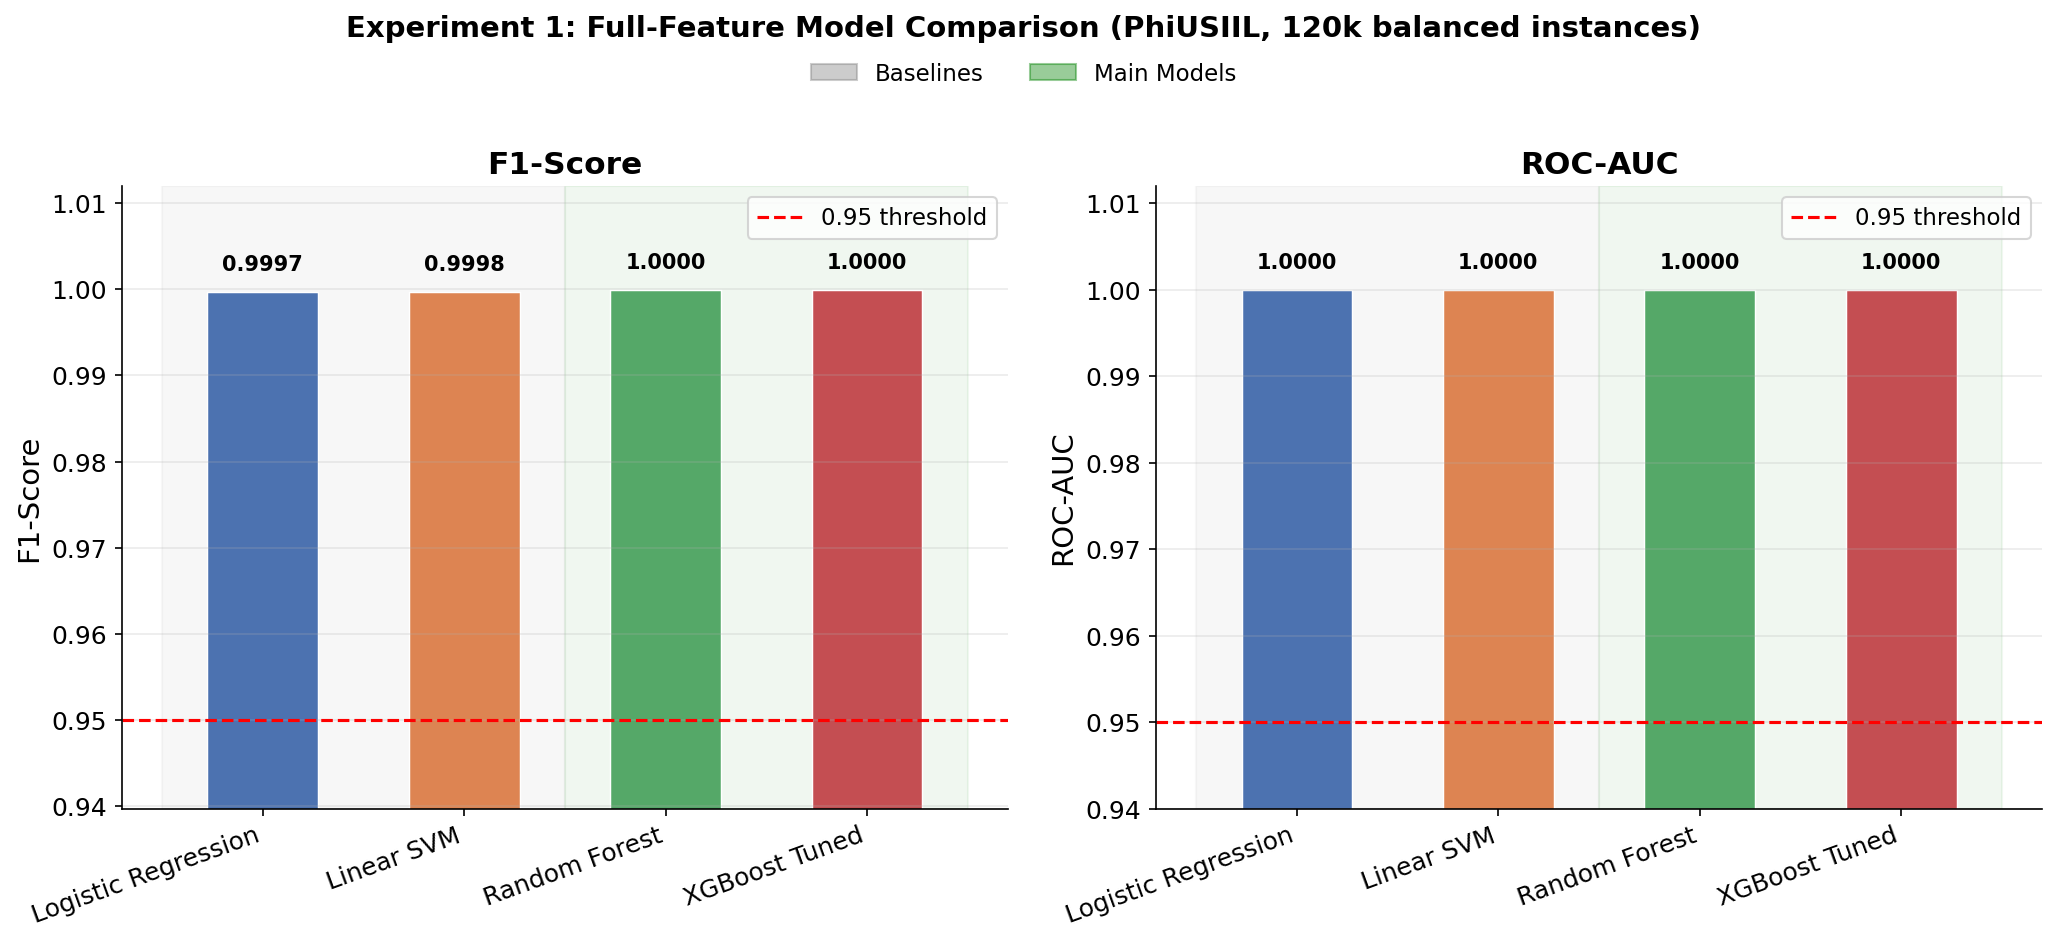

In [ ]:
# ============================================================
# Cell 8: Figure A1 -- Full-Feature Model Comparison
# ============================================================

MODEL_COLORS = {
    'Logistic Regression': '#4C72B0',
    'Linear SVM'         : '#DD8452',
    'Random Forest'      : '#55A868',
    'XGBoost Tuned'      : '#C44E52',
}
names  = df_res_full['Model'].tolist()
colors = [MODEL_COLORS.get(n, '#888') for n in names]
types  = df_res_full['Model Type'].tolist()
n_base = sum(1 for t in types if t == 'Baseline')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, metric, ylabel in zip(axes, ['F1','ROC_AUC'], ['F1-Score','ROC-AUC']):
    vals  = df_res_full[metric].values
    bars  = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=0.7, width=0.55)
    ax.axhline(0.95, color='red', linestyle='--', linewidth=1.5, label='0.95 threshold')
    ax.set_ylim(max(0, vals.min() - 0.06), 1.012)
    ax.set_title(ylabel, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(names, rotation=20, ha='right', fontsize=12)
    # shade regions
    ax.axvspan(-0.5,       n_base - 0.5,  alpha=0.06, color='grey',  zorder=0)
    ax.axvspan(n_base-0.5, len(names)-0.5, alpha=0.06, color='green', zorder=0)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.002,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.25)

base_patch = mpatches.Patch(color='grey',  alpha=0.4, label='Baselines')
main_patch = mpatches.Patch(color='green', alpha=0.4, label='Main Models')
fig.legend(handles=[base_patch, main_patch], loc='upper center',
           ncol=2, fontsize=11, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Experiment 1: Full-Feature Model Comparison (PhiUSIIL, 120k balanced instances)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
save_fig(fig, 'main_full_feature_model_comparison_metrics')
plt.show()


  Saved random_forest_confusion_matrix_full_features.png / .pdf


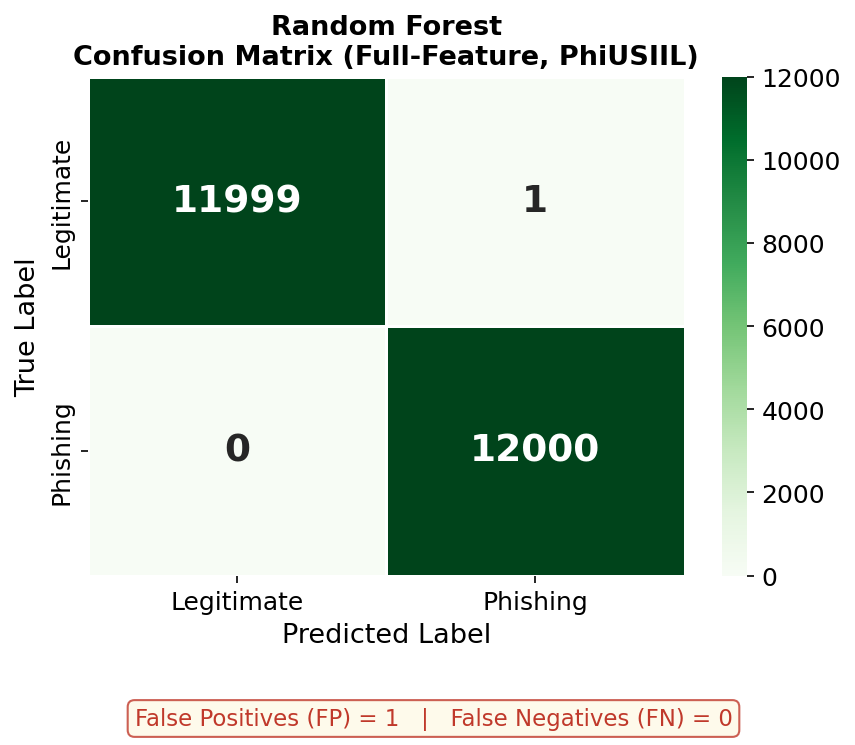

  Saved xgboost_confusion_matrix_full_features.png / .pdf


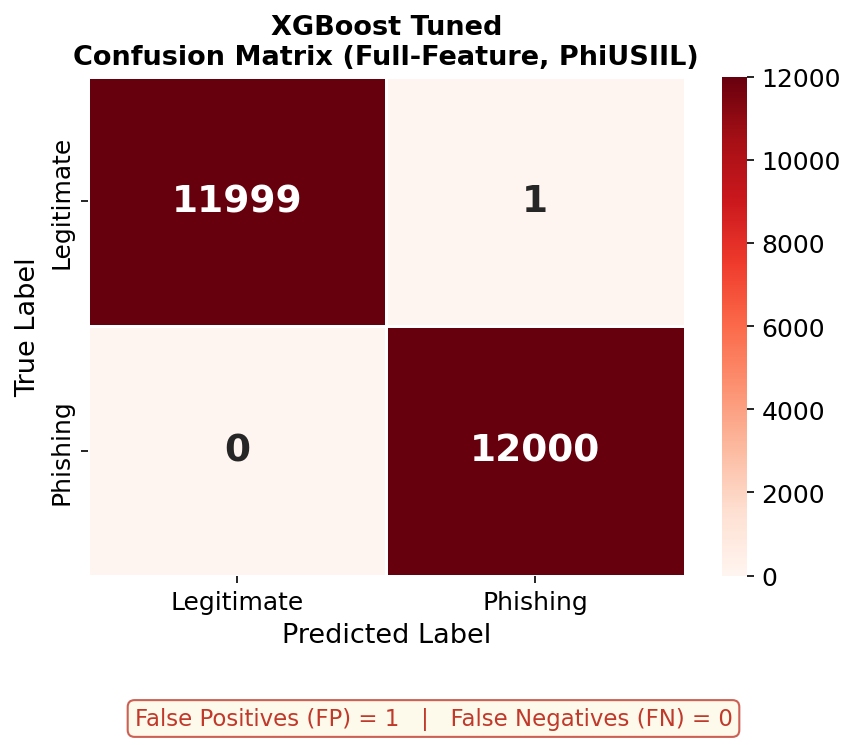

In [ ]:
# ============================================================
# Cell 9: Figures A2 & A3 -- Confusion Matrices
# ============================================================
# FP/FN counts displayed in a subtitle box, NOT inside the
# heatmap, to avoid label overlap.
# ============================================================

def plot_cm(cm_arr, title, stem, cmap):
    tn,fp,fn,tp_ = cm_arr.ravel()
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm_arr, annot=True, fmt='d', cmap=cmap,
        xticklabels=['Legitimate','Phishing'],
        yticklabels=['Legitimate','Phishing'],
        annot_kws={'size':18,'weight':'bold'},
        ax=ax, linewidths=0.5, cbar=True,
    )
    ax.set_xlabel('Predicted Label', fontsize=13)
    ax.set_ylabel('True Label',      fontsize=13)
    ax.set_title(title,              fontsize=13, fontweight='bold')
    fig.text(
        0.5, 0.01,
        f'False Positives (FP) = {fp}   |   False Negatives (FN) = {fn}',
        ha='center', fontsize=11, color='#c0392b',
        bbox=dict(boxstyle='round,pad=0.3', fc='#fef9e7', ec='#c0392b', alpha=0.8),
    )
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    save_fig(fig, stem)
    plt.show()

for mname, stem, cmap in [
    ('Random Forest', 'random_forest_confusion_matrix_full_features', 'Greens'),
    ('XGBoost Tuned', 'xgboost_confusion_matrix_full_features',       'Reds'),
]:
    rd = next((r for r in results_full if r['Model'] == mname), None)
    if rd is None:
        print(f"  Skipping CM for {mname} (model not available).")
        continue
    plot_cm(rd['CM'], f'{mname}\nConfusion Matrix (Full-Feature, PhiUSIIL)', stem, cmap)


  Saved roc_curves_full_features.png / .pdf


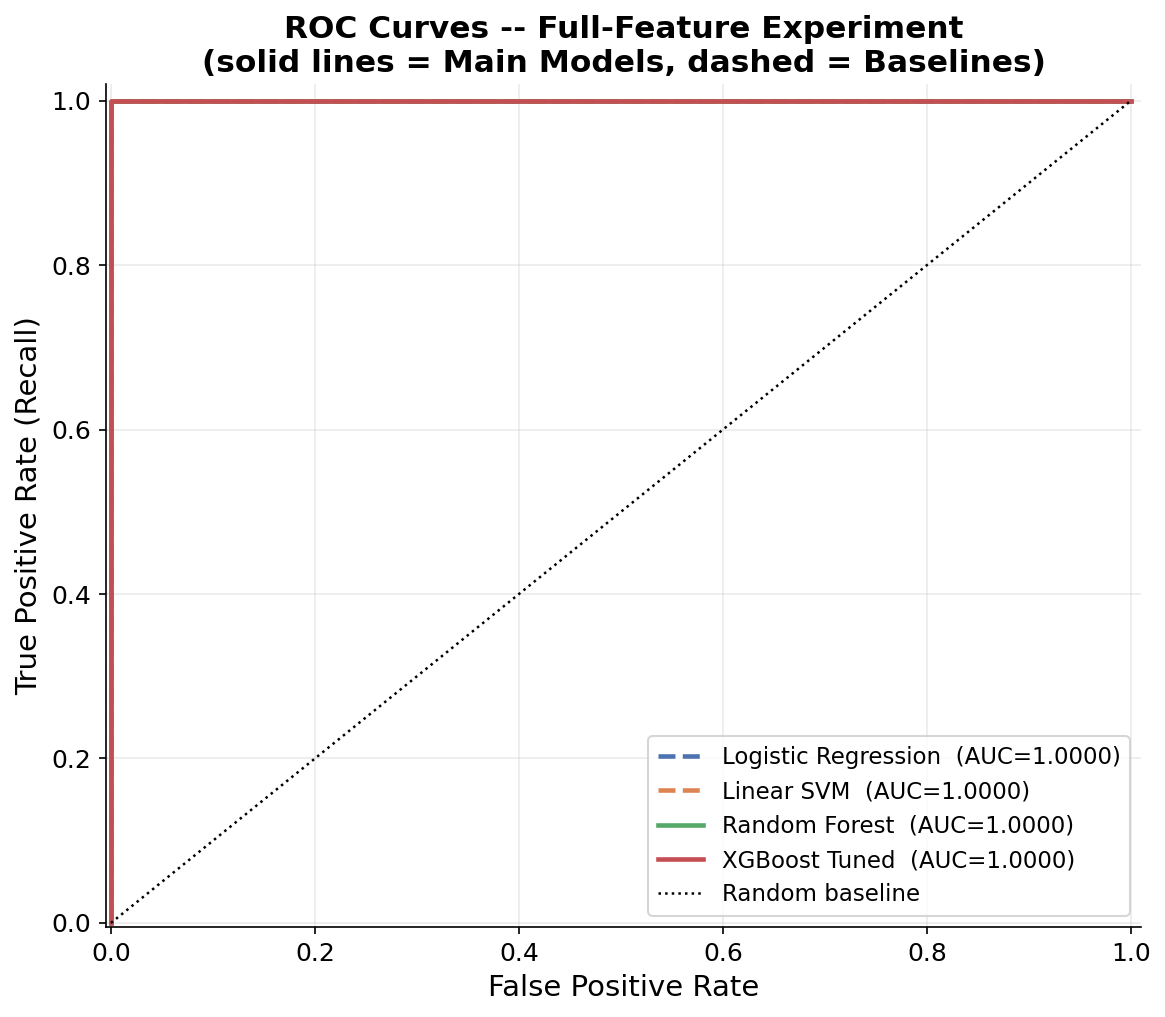

In [ ]:
# ============================================================
# Cell 10: Figure A4 -- ROC Curves (Full-Feature)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))
for r in results_full:
    fpr_arr, tpr_arr, _ = roc_curve(y_te, r['y_proba'])
    ls    = '--' if r['Model Type'] == 'Baseline' else '-'
    color = MODEL_COLORS.get(r['Model'], '#888')
    ax.plot(fpr_arr, tpr_arr, lw=2.2, color=color, linestyle=ls,
            label=f"{r['Model']}  (AUC={r['ROC_AUC']:.4f})")

ax.plot([0,1],[0,1], 'k:', lw=1.2, label='Random baseline')
ax.set_xlim([-0.005,1.01]); ax.set_ylim([-0.005,1.02])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curves -- Full-Feature Experiment\n'
             '(solid lines = Main Models, dashed = Baselines)',
             fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.25)
plt.tight_layout()
save_fig(fig, 'roc_curves_full_features')
plt.show()


  Saved random_forest_feature_importance_full_features.png / .pdf


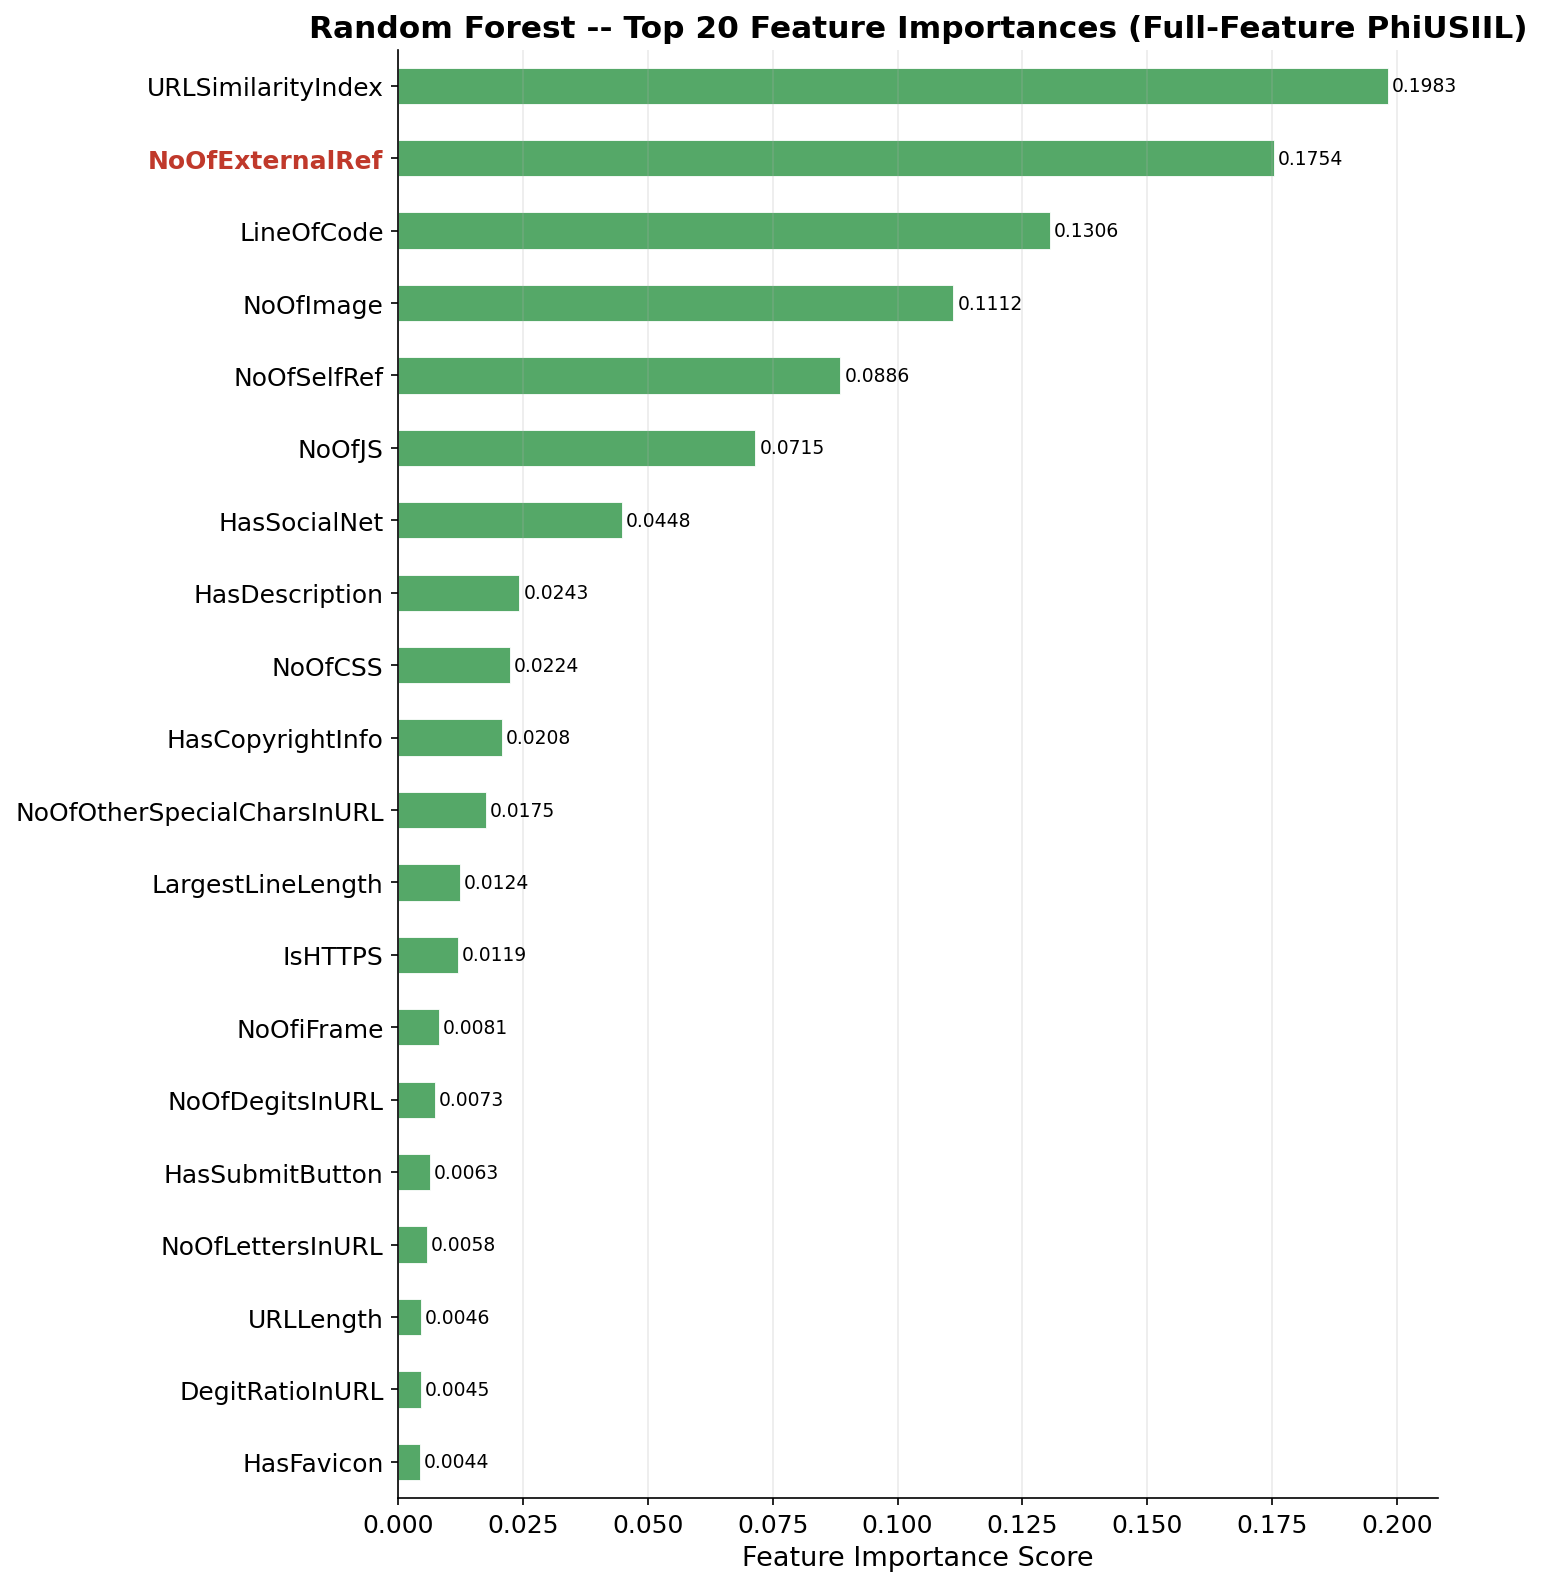

  NoOfExternalRef: rank=2, importance=0.1754
  Saved xgboost_feature_importance_full_features.png / .pdf


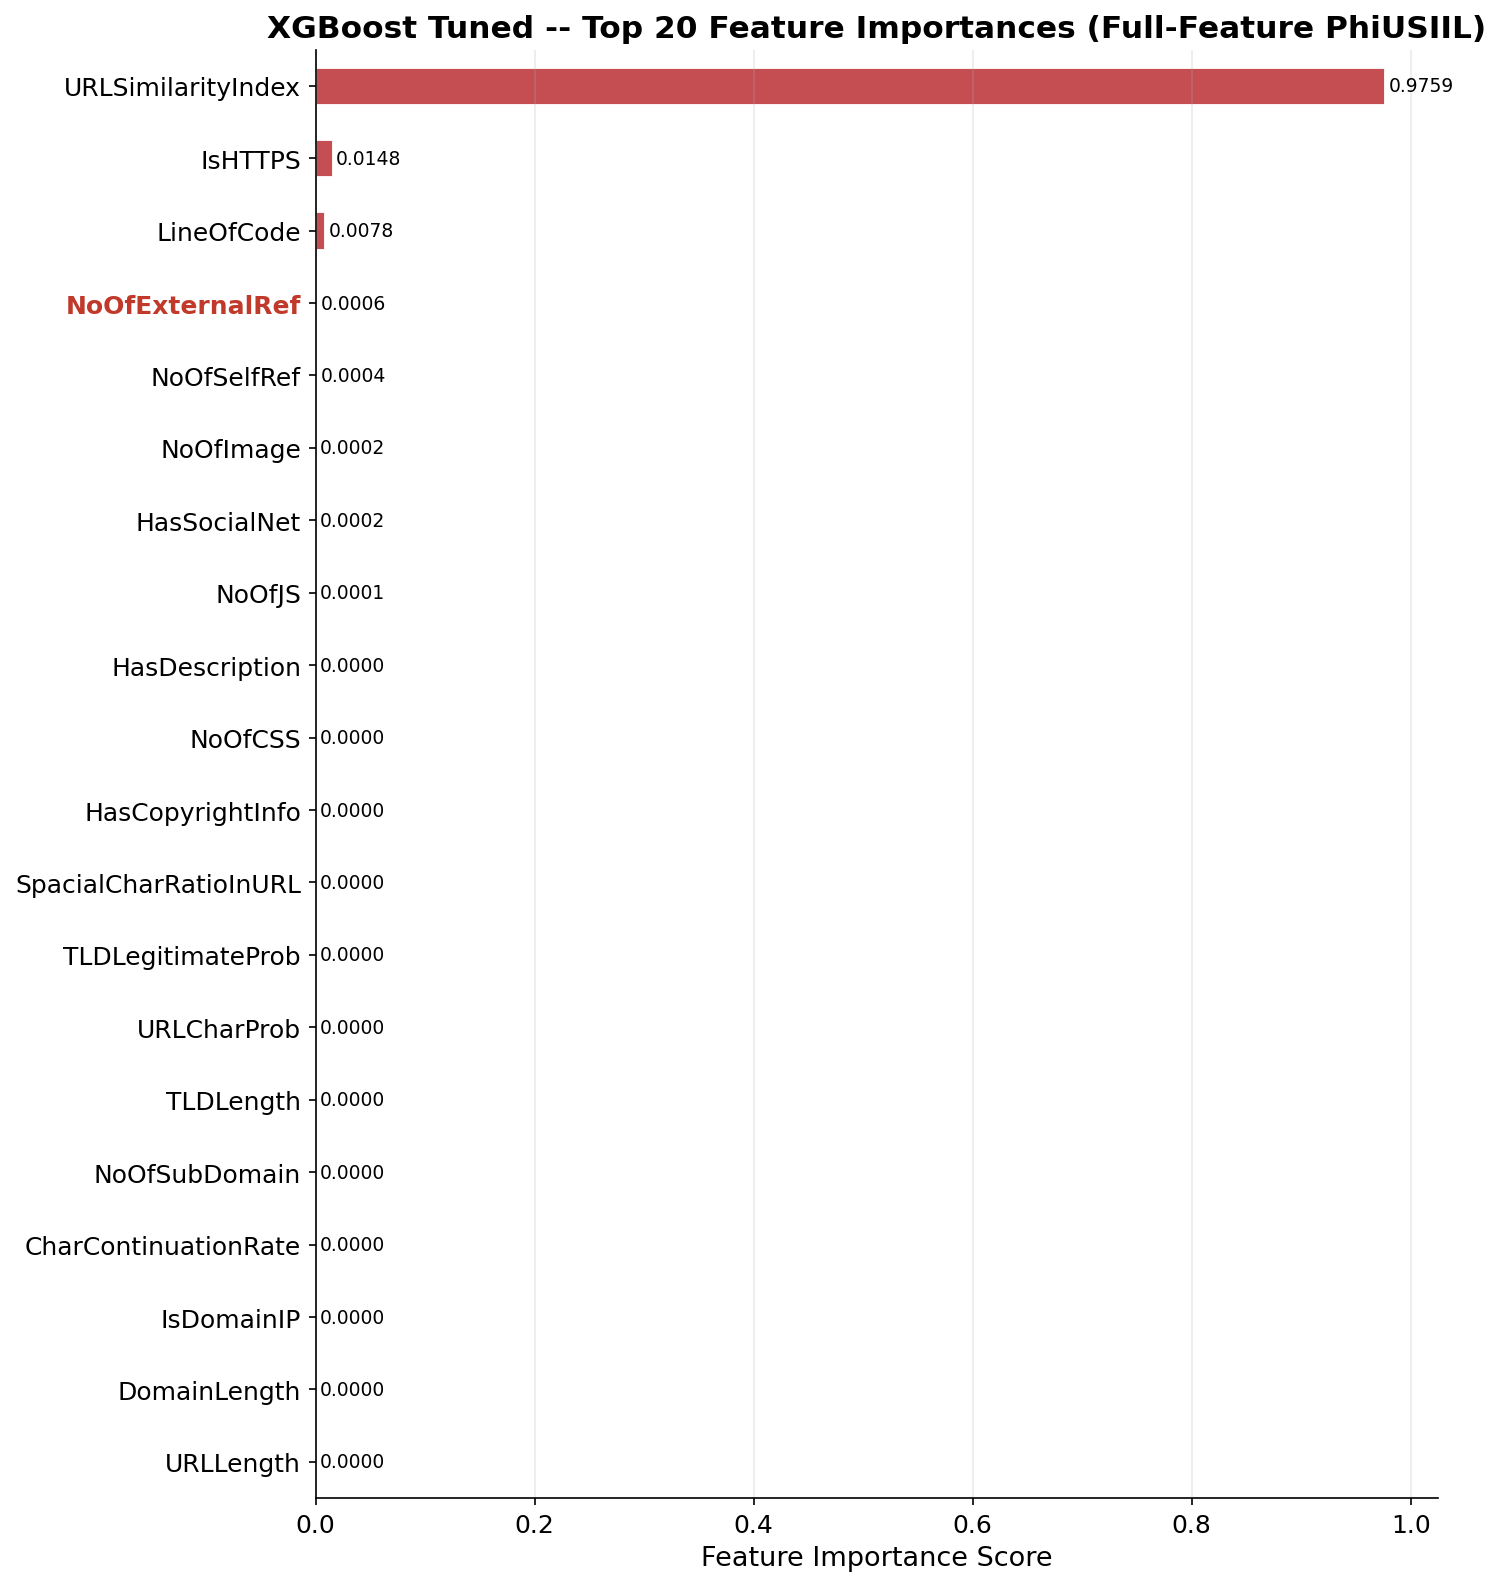

  NoOfExternalRef: rank=4, importance=0.0006


In [ ]:
# ============================================================
# Cell 11: Figures A5 & A6 -- Feature Importance (Top 20)
# ============================================================

NOOFEXT = 'NoOfExternalRef'
TOP_N   = 20
_fi_imp = {}   # store importance Series for later

def plot_fi(model, feat_names, title, stem, color, top_n=TOP_N):
    imp  = pd.Series(model.feature_importances_, index=feat_names)
    _fi_imp[stem] = imp
    top  = imp.nlargest(top_n).sort_values()

    fig, ax = plt.subplots(figsize=(10, top_n * 0.44 + 2))
    top.plot(kind='barh', ax=ax, color=color, edgecolor='white', linewidth=0.4)

    # Highlight NoOfExternalRef tick label in red if present
    ax.figure.canvas.draw()
    for lbl in ax.get_yticklabels():
        if NOOFEXT in lbl.get_text():
            lbl.set_color('#c0392b')
            lbl.set_fontweight('bold')

    ax.set_xlabel('Feature Importance Score', fontsize=13)
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.25)
    for i, (v, n) in enumerate(zip(top.values, top.index)):
        ax.text(v + top.max() * 0.004, i, f'{v:.4f}', va='center', fontsize=9)
    plt.tight_layout()
    save_fig(fig, stem)
    plt.show()

    # Report rank of NoOfExternalRef
    if NOOFEXT in imp.index:
        rank = int(imp.rank(ascending=False).astype(int)[NOOFEXT])
        val  = float(imp[NOOFEXT])
        print(f"  {NOOFEXT}: rank={rank}, importance={val:.4f}")
    else:
        print(f"  NOTE: '{NOOFEXT}' not found in feature set for {stem}.")
    return imp

rf_imp = plot_fi(
    rf, FEATURE_COLS,
    f'Random Forest -- Top {TOP_N} Feature Importances (Full-Feature PhiUSIIL)',
    'random_forest_feature_importance_full_features', '#55A868',
)

if xgb_best is not None:
    xgb_imp = plot_fi(
        xgb_best, FEATURE_COLS,
        f'XGBoost Tuned -- Top {TOP_N} Feature Importances (Full-Feature PhiUSIIL)',
        'xgboost_feature_importance_full_features', '#C44E52',
    )


Computing SHAP values (RF, full-feature) -- may take 1-3 minutes ...


100%|===================| 3981/4000 [02:22<00:00]       


Top 15 SHAP features (mean |SHAP value|):
   1. URLSimilarityIndex                      0.25910
   2. LineOfCode                              0.05792
   3. IsHTTPS                                 0.04851
   4. NoOfSelfRef                             0.02483
   5. NoOfImage                               0.01988
   6. NoOfOtherSpecialCharsInURL              0.01045
   7. NoOfExternalRef                         0.00967  <-- NoOfExternalRef
   8. NoOfSubDomain                           0.00660
   9. HasSocialNet                            0.00596
  10. NoOfJS                                  0.00547
  11. NoOfDegitsInURL                         0.00519
  12. LetterRatioInURL                        0.00518
  13. NoOfCSS                                 0.00511
  14. URLLength                               0.00503
  15. HasDescription                          0.00430

  NoOfExternalRef: SHAP rank=7, mean|SHAP|=0.00967
  NOTE: Top SHAP feature is 'URLSimilarityIndex', not NoOfExternalRef. Rep

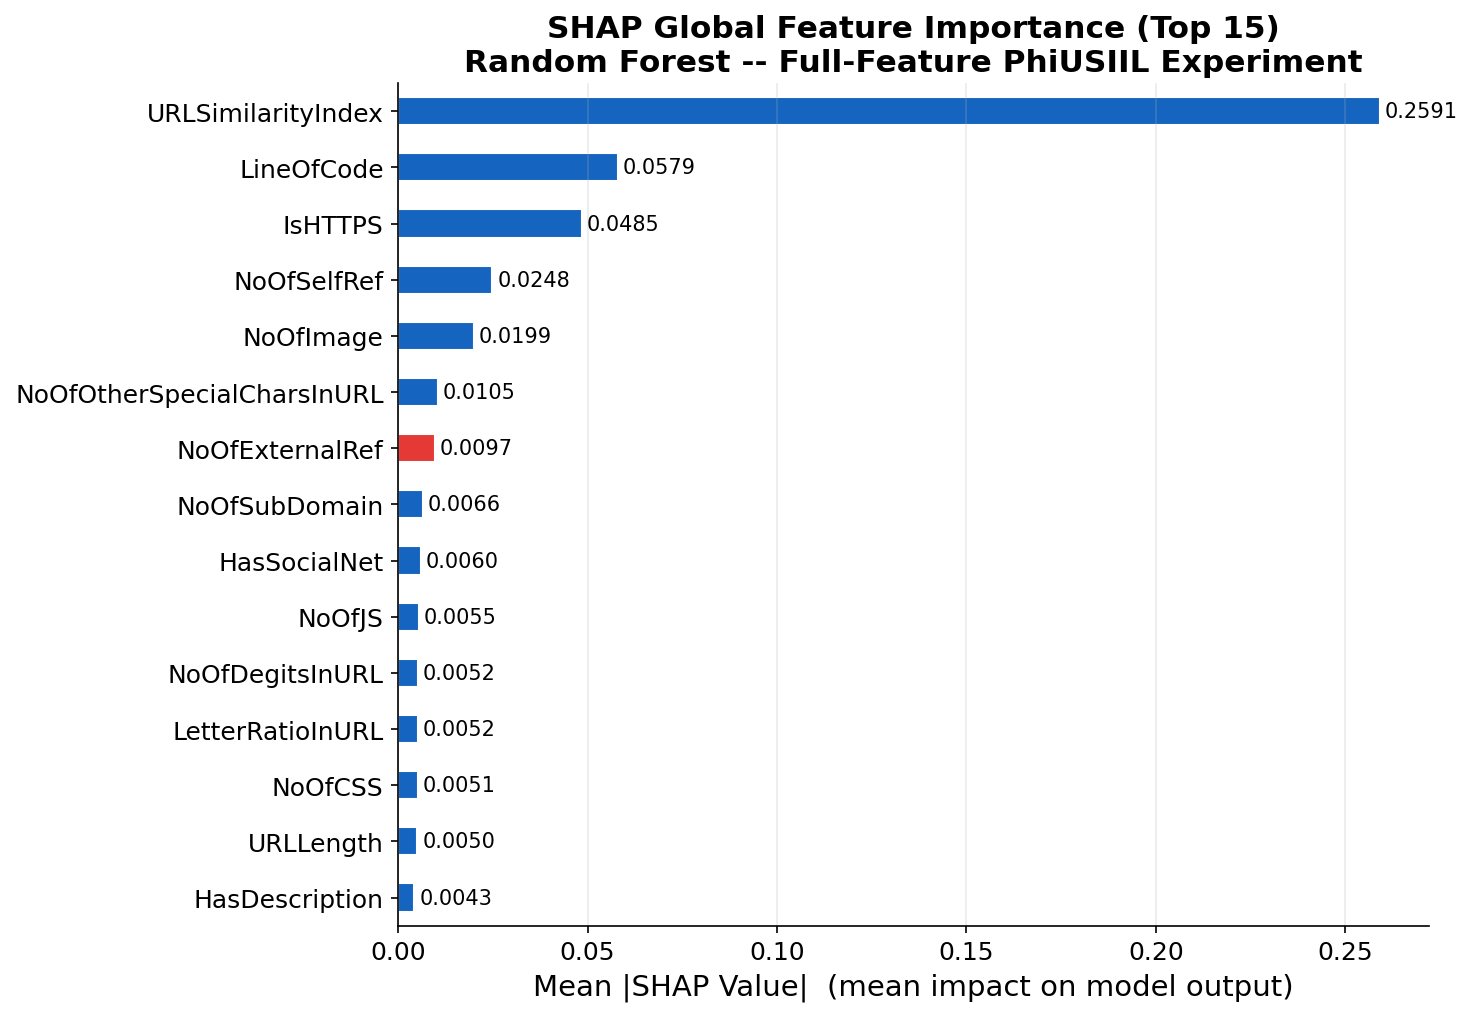

In [ ]:
    shap_imp_series = None

    if SHAP_AVAILABLE:
        print("Computing SHAP values (RF, full-feature) -- may take 1-3 minutes ...")
        bg        = shap.sample(X_tr, 500, random_state=RANDOM_STATE)
        explainer = shap.TreeExplainer(rf, data=bg,
                                       feature_perturbation='interventional')
        n_shap    = min(2000, len(X_te))
        idx_s     = np.random.choice(len(X_te), n_shap, replace=False)
        X_shap    = X_te.iloc[idx_s]

        sv_raw = explainer.shap_values(X_shap)

        # Ensure we get a 2D array of (n_samples, n_features) for the positive class
        if isinstance(sv_raw, list):
            sv_class_1 = sv_raw[1] # SHAP values for the positive class (class index 1)
        else:
            # If shap_values returns a 3D array (n_samples, n_features, n_classes)
            sv_class_1 = sv_raw[:, :, 1] # Select SHAP values for the positive class

        shap_imp_series = pd.Series(np.abs(sv_class_1).mean(axis=0), index=FEATURE_COLS)
        SHAP_TOP = 15
        top_shap = shap_imp_series.nlargest(SHAP_TOP).sort_values()

        print(f"\nTop {SHAP_TOP} SHAP features (mean |SHAP value|):")
        for i, (fname, val) in enumerate(shap_imp_series.nlargest(SHAP_TOP).items()):
            marker = '  <-- NoOfExternalRef' if fname == NOOFEXT else ''
            print(f"  {i+1:>2}. {fname:38s}  {val:.5f}{marker}")

        # Report rank honestly -- do NOT assume NoOfExternalRef is #1
        if NOOFEXT in shap_imp_series.index:
            shap_rank = int(shap_imp_series.rank(ascending=False).astype(int)[NOOFEXT])
            shap_val_ = float(shap_imp_series[NOOFEXT])
            top1_name = shap_imp_series.idxmax()
            print(f"\n  {NOOFEXT}: SHAP rank={shap_rank}, mean|SHAP|={shap_val_:.5f}")
            if top1_name != NOOFEXT:
                print(f"  NOTE: Top SHAP feature is '{top1_name}', not {NOOFEXT}. "
                      "Reporting this honestly.")
        else:
            print(f"  NOTE: '{NOOFEXT}' not found in SHAP results.")

        # Plot
        colors_shap = ['#e53935' if n == NOOFEXT else '#1565C0' for n in top_shap.index]
        fig, ax = plt.subplots(figsize=(10, 7))
        top_shap.plot(kind='barh', ax=ax, color=colors_shap, edgecolor='white')
        ax.set_xlabel('Mean |SHAP Value|  (mean impact on model output)')
        ax.set_title(f'SHAP Global Feature Importance (Top {SHAP_TOP})\n'
                     'Random Forest -- Full-Feature PhiUSIIL Experiment',
                     fontweight='bold')
        ax.grid(axis='x', alpha=0.25)
        for i, (v, n) in enumerate(zip(top_shap.values, top_shap.index)):
            ax.text(v + top_shap.max()*0.005, i, f'{v:.4f}', va='center', fontsize=10)
        plt.tight_layout()
        save_fig(fig, 'shap_global_importance_full_features')
        plt.show()
    else:
        print("SHAP not installed -- skipping.  pip install shap")

In [ ]:
# ============================================================
# Cell 13a: Install LIME (run once if LIME is not installed)
# ============================================================
# If LIME was skipped in a prior run because it wasn't installed,
# run this cell first, then restart the kernel and re-run from Cell 1.
# ============================================================

import subprocess, sys
import importlib.metadata # Added for robust version checking

try:
    from lime.lime_tabular import LimeTabularExplainer
    print("LIME is already installed -- no action needed.")
except ImportError:
    print("Installing LIME ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lime", "--quiet"])
    from lime.lime_tabular import LimeTabularExplainer
    print("LIME installed successfully.")

# Re-check global flag
try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
    try:
        # Use importlib.metadata to get the version reliably
        lime_version = importlib.metadata.version("lime")
        print(f"LIME version : {lime_version}")
    except importlib.metadata.PackageNotFoundError:
        print("LIME package found, but version could not be determined.")
    except Exception as e:
        print(f"An unexpected error occurred while getting LIME version: {e}")
except ImportError:
    LIME_AVAILABLE = False
    print("ERROR: LIME installation failed. Try: pip install lime")

LIME is already installed -- no action needed.
LIME version : 0.2.0.1


Using LIME version: 0.2.0.1
Generating LIME local explanation (RF, full-feature) ...
  Using test-set instance index 0 (correctly classified phishing).
  Saved: outputs/explanations/lime_local_explanation_full_features.html

  Top LIME contributing features:
    51.43 < URLSimilarityIndex <= 100.00                  +0.0852  -> PHISHING
    0.00 < IsHTTPS <= 1.00                                +0.0829  -> PHISHING
    NoOfAmpersandInURL <= 0.00                            -0.0570  -> LEGITIMATE
    271.00 < LineOfCode <= 1104.00                        +0.0392  -> PHISHING
    IsDomainIP <= 0.00                                    -0.0364  -> LEGITIMATE
    ObfuscationRatio <= 0.00                              +0.0362  -> PHISHING
    2.00 < NoOfSelfRef <= 75.00                           +0.0305  -> PHISHING
    HasObfuscation <= 0.00                                +0.0257  -> PHISHING
    NoOfDegitsInURL <= 0.00                               +0.0206  -> PHISHING
    NoOfOtherSpecialCharsI

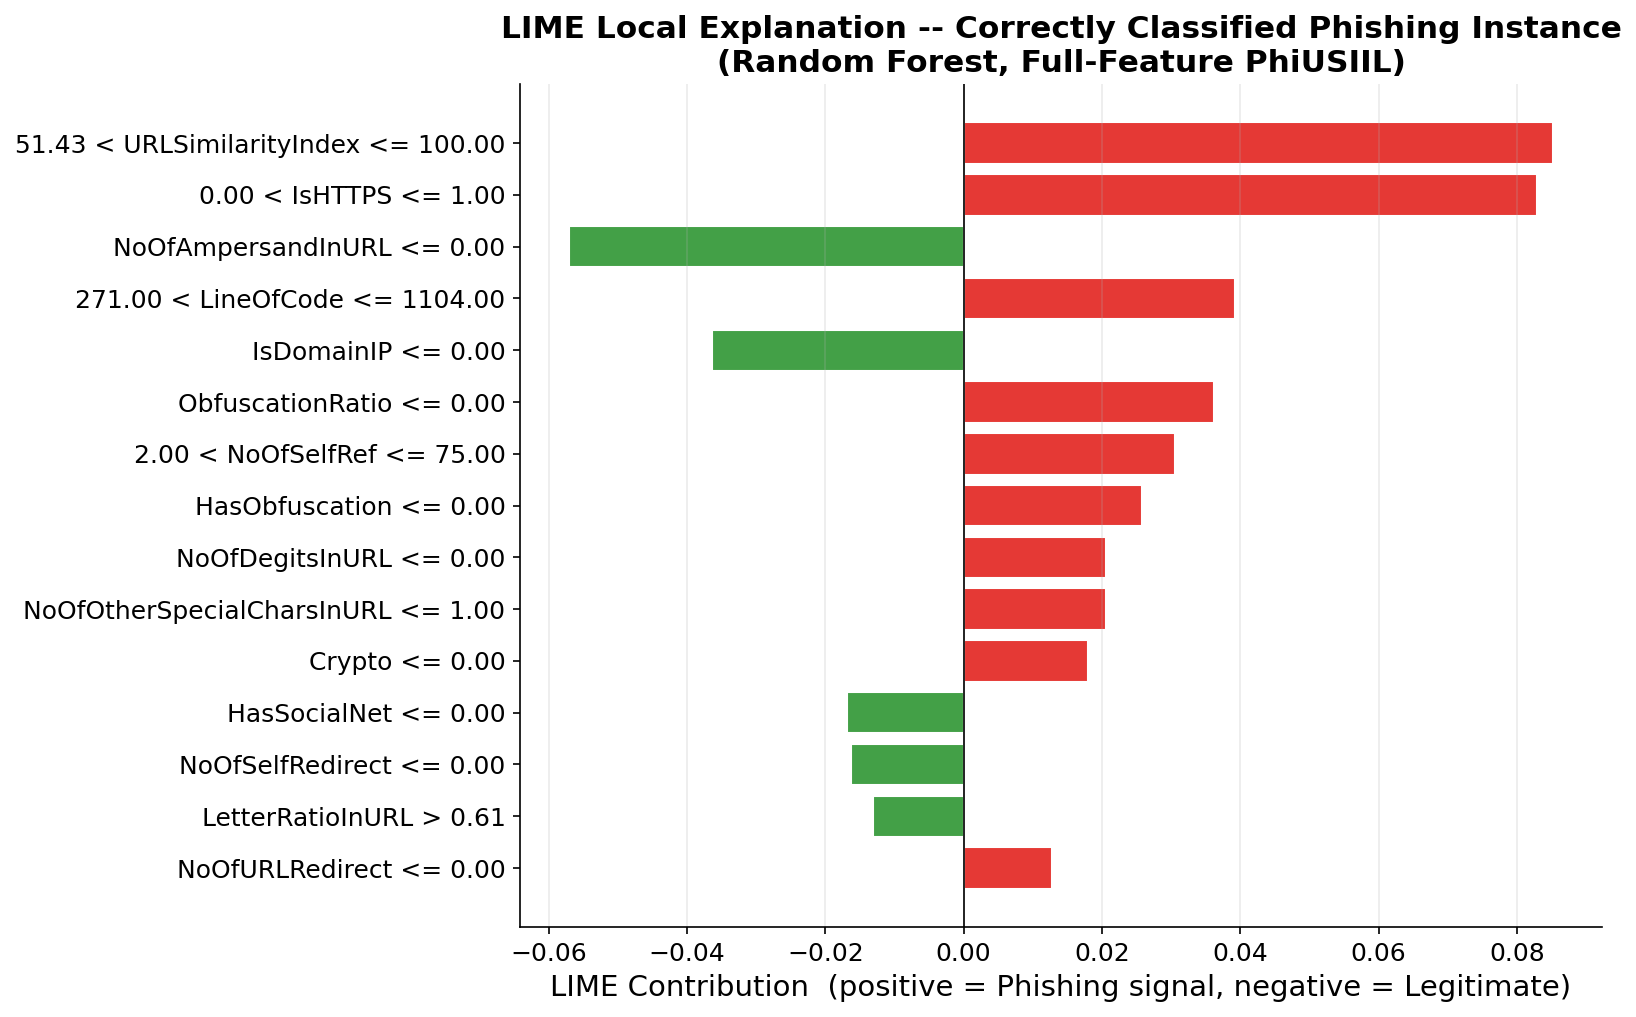

  Saved: lime_top_features_full_features.png / .pdf


In [ ]:
# ============================================================
# Cell 13b: LIME Local Explanation (Full-Feature, RF)
# ============================================================
# Generates:
#   outputs/explanations/lime_local_explanation_full_features.html
#   outputs/figures/lime_top_features_full_features.png / .pdf
# ============================================================

import importlib.metadata # Added for robust version checking

# Re-check LIME availability and get version reliably
try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
    try:
        lime_version = importlib.metadata.version("lime")
        print(f"Using LIME version: {lime_version}")
    except importlib.metadata.PackageNotFoundError:
        print("LIME package found, but version could not be determined.")
    except Exception as e:
        print(f"An unexpected error occurred while getting LIME version: {e}")
except ImportError:
    LIME_AVAILABLE = False
    print("LIME is not installed or import failed for LimeTabularExplainer.")


if LIME_AVAILABLE:
    print("Generating LIME local explanation (RF, full-feature) ...")

    lime_exp_obj = LimeTabularExplainer(
        training_data = X_tr.values,
        feature_names = FEATURE_COLS,
        class_names   = ['Legitimate', 'Phishing'],
        mode          = 'classification',
        random_state  = RANDOM_STATE,
    )

    # Find a correctly classified phishing instance from the test set
    y_pred_te    = rf.predict(X_te)
    correct_mask = (y_pred_te == 1) & (y_te.values == 1)
    idxs         = np.where(correct_mask)[0]
    if len(idxs) == 0:
        print("  WARNING: No correctly-classified phishing instance found; using index 0.")
        lime_idx = 0
    else:
        lime_idx = idxs[0]
        print(f"  Using test-set instance index {lime_idx} (correctly classified phishing).")

    lime_exp = lime_exp_obj.explain_instance(
        data_row   = X_te.iloc[lime_idx].values,
        predict_fn = rf.predict_proba,
        num_features = 15,
        num_samples  = 3000,
    )

    # Save HTML
    html_path = str(OUTPUT_DIR / 'explanations' / 'lime_local_explanation_full_features.html')
    lime_exp.save_to_file(html_path)
    print(f"  Saved: {html_path}")

    # Print top features
    feats_raw = lime_exp.as_list()
    print("\n  Top LIME contributing features:")
    for label_l, val_l in feats_raw:
        direction = "-> PHISHING" if val_l > 0 else "-> LEGITIMATE"
        print(f"    {label_l:52s}  {val_l:+.4f}  {direction}")

    # Bar chart
    labels_l = [x[0] for x in feats_raw]
    vals_l   = [x[1] for x in feats_raw]
    col_l    = ['#e53935' if v > 0 else '#43a047' for v in vals_l]

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(labels_l[::-1], vals_l[::-1], color=col_l[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('LIME Contribution  (positive = Phishing signal, negative = Legitimate)')
    ax.set_title('LIME Local Explanation -- Correctly Classified Phishing Instance\n'
                 '(Random Forest, Full-Feature PhiUSIIL)',
                 fontweight='bold')
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    save_fig(fig, 'lime_top_features_full_features')
    plt.show()
    print("  Saved: lime_top_features_full_features.png / .pdf")
else:
    print("ERROR: LIME is not available. Run Cell 13a first, then restart the kernel.")

NoOfExternalRef ANALYSIS

Random Forest: rank=2, importance=0.1754
XGBoost Tuned: rank=4, importance=0.0006
SHAP (RF):     rank=7, mean|SHAP|=0.00967
  (Top SHAP feature is 'URLSimilarityIndex', not NoOfExternalRef -- reporting honestly.)
  Saved noofexternalref_distribution_by_class.png / .pdf


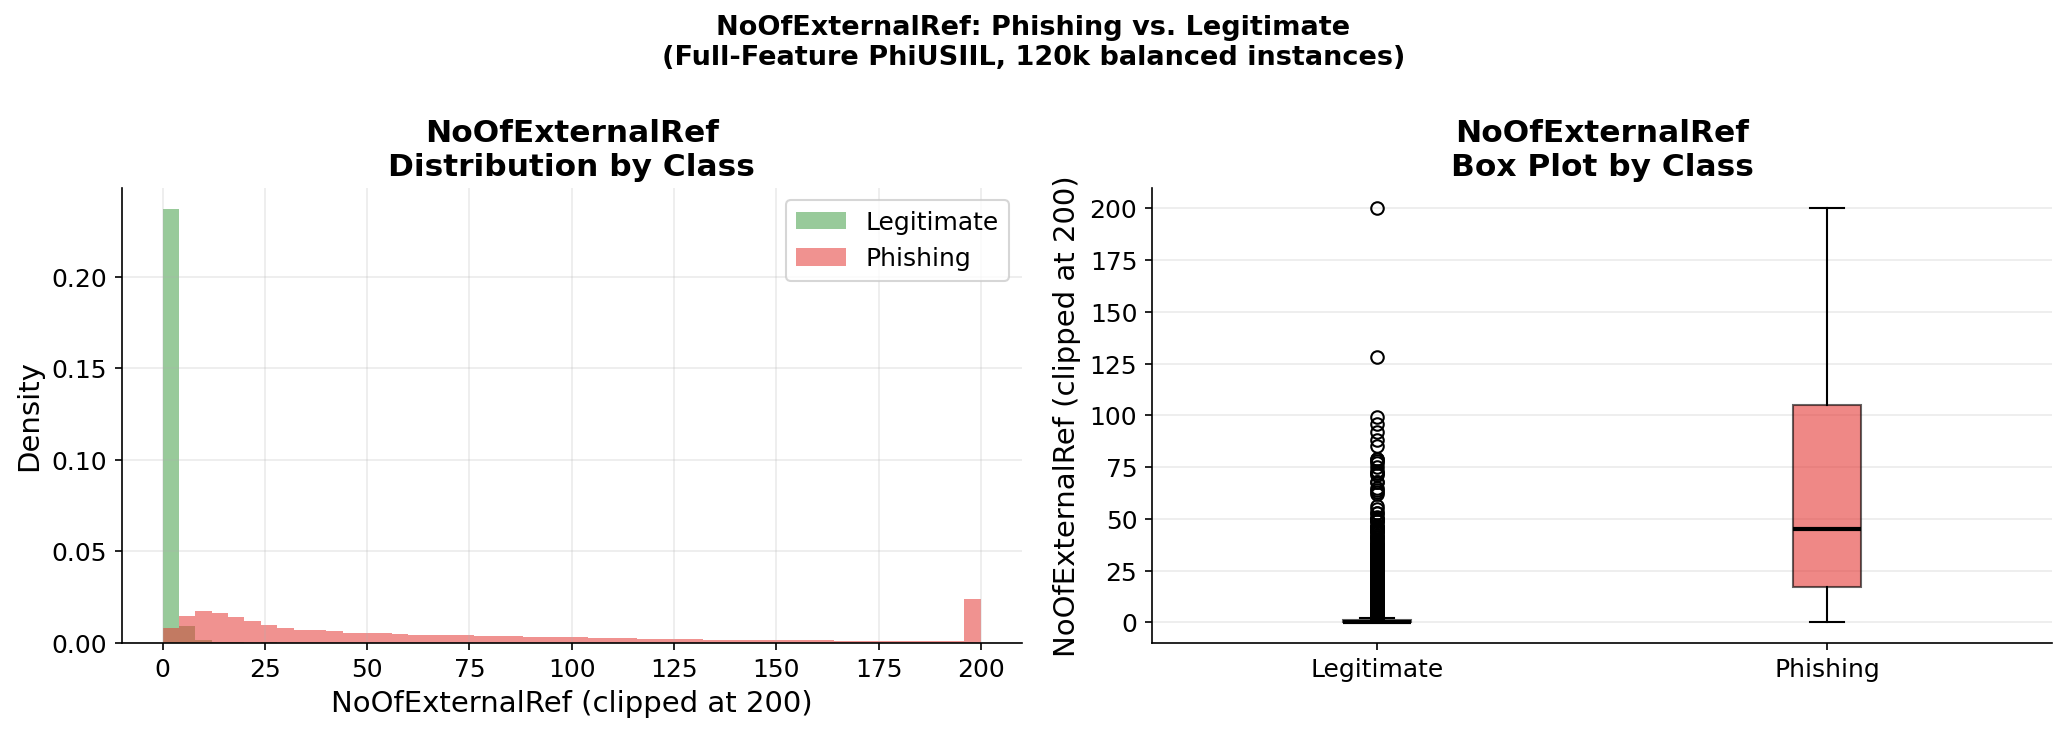


Sensitivity analysis on 12,000 correctly classified phishing samples ...
  NoOfExternalRef = 0                               : 0/12,000 flipped (0.0%)
  NoOfExternalRef = 1                               : 0/12,000 flipped (0.0%)
  NoOfExternalRef = 5                               : 0/12,000 flipped (0.0%)
  NoOfExternalRef = Legit Median (0)                : 0/12,000 flipped (0.0%)
  Saved: noofexternalref_sensitivity_analysis.csv
  Saved noofexternalref_sensitivity_analysis.png / .pdf


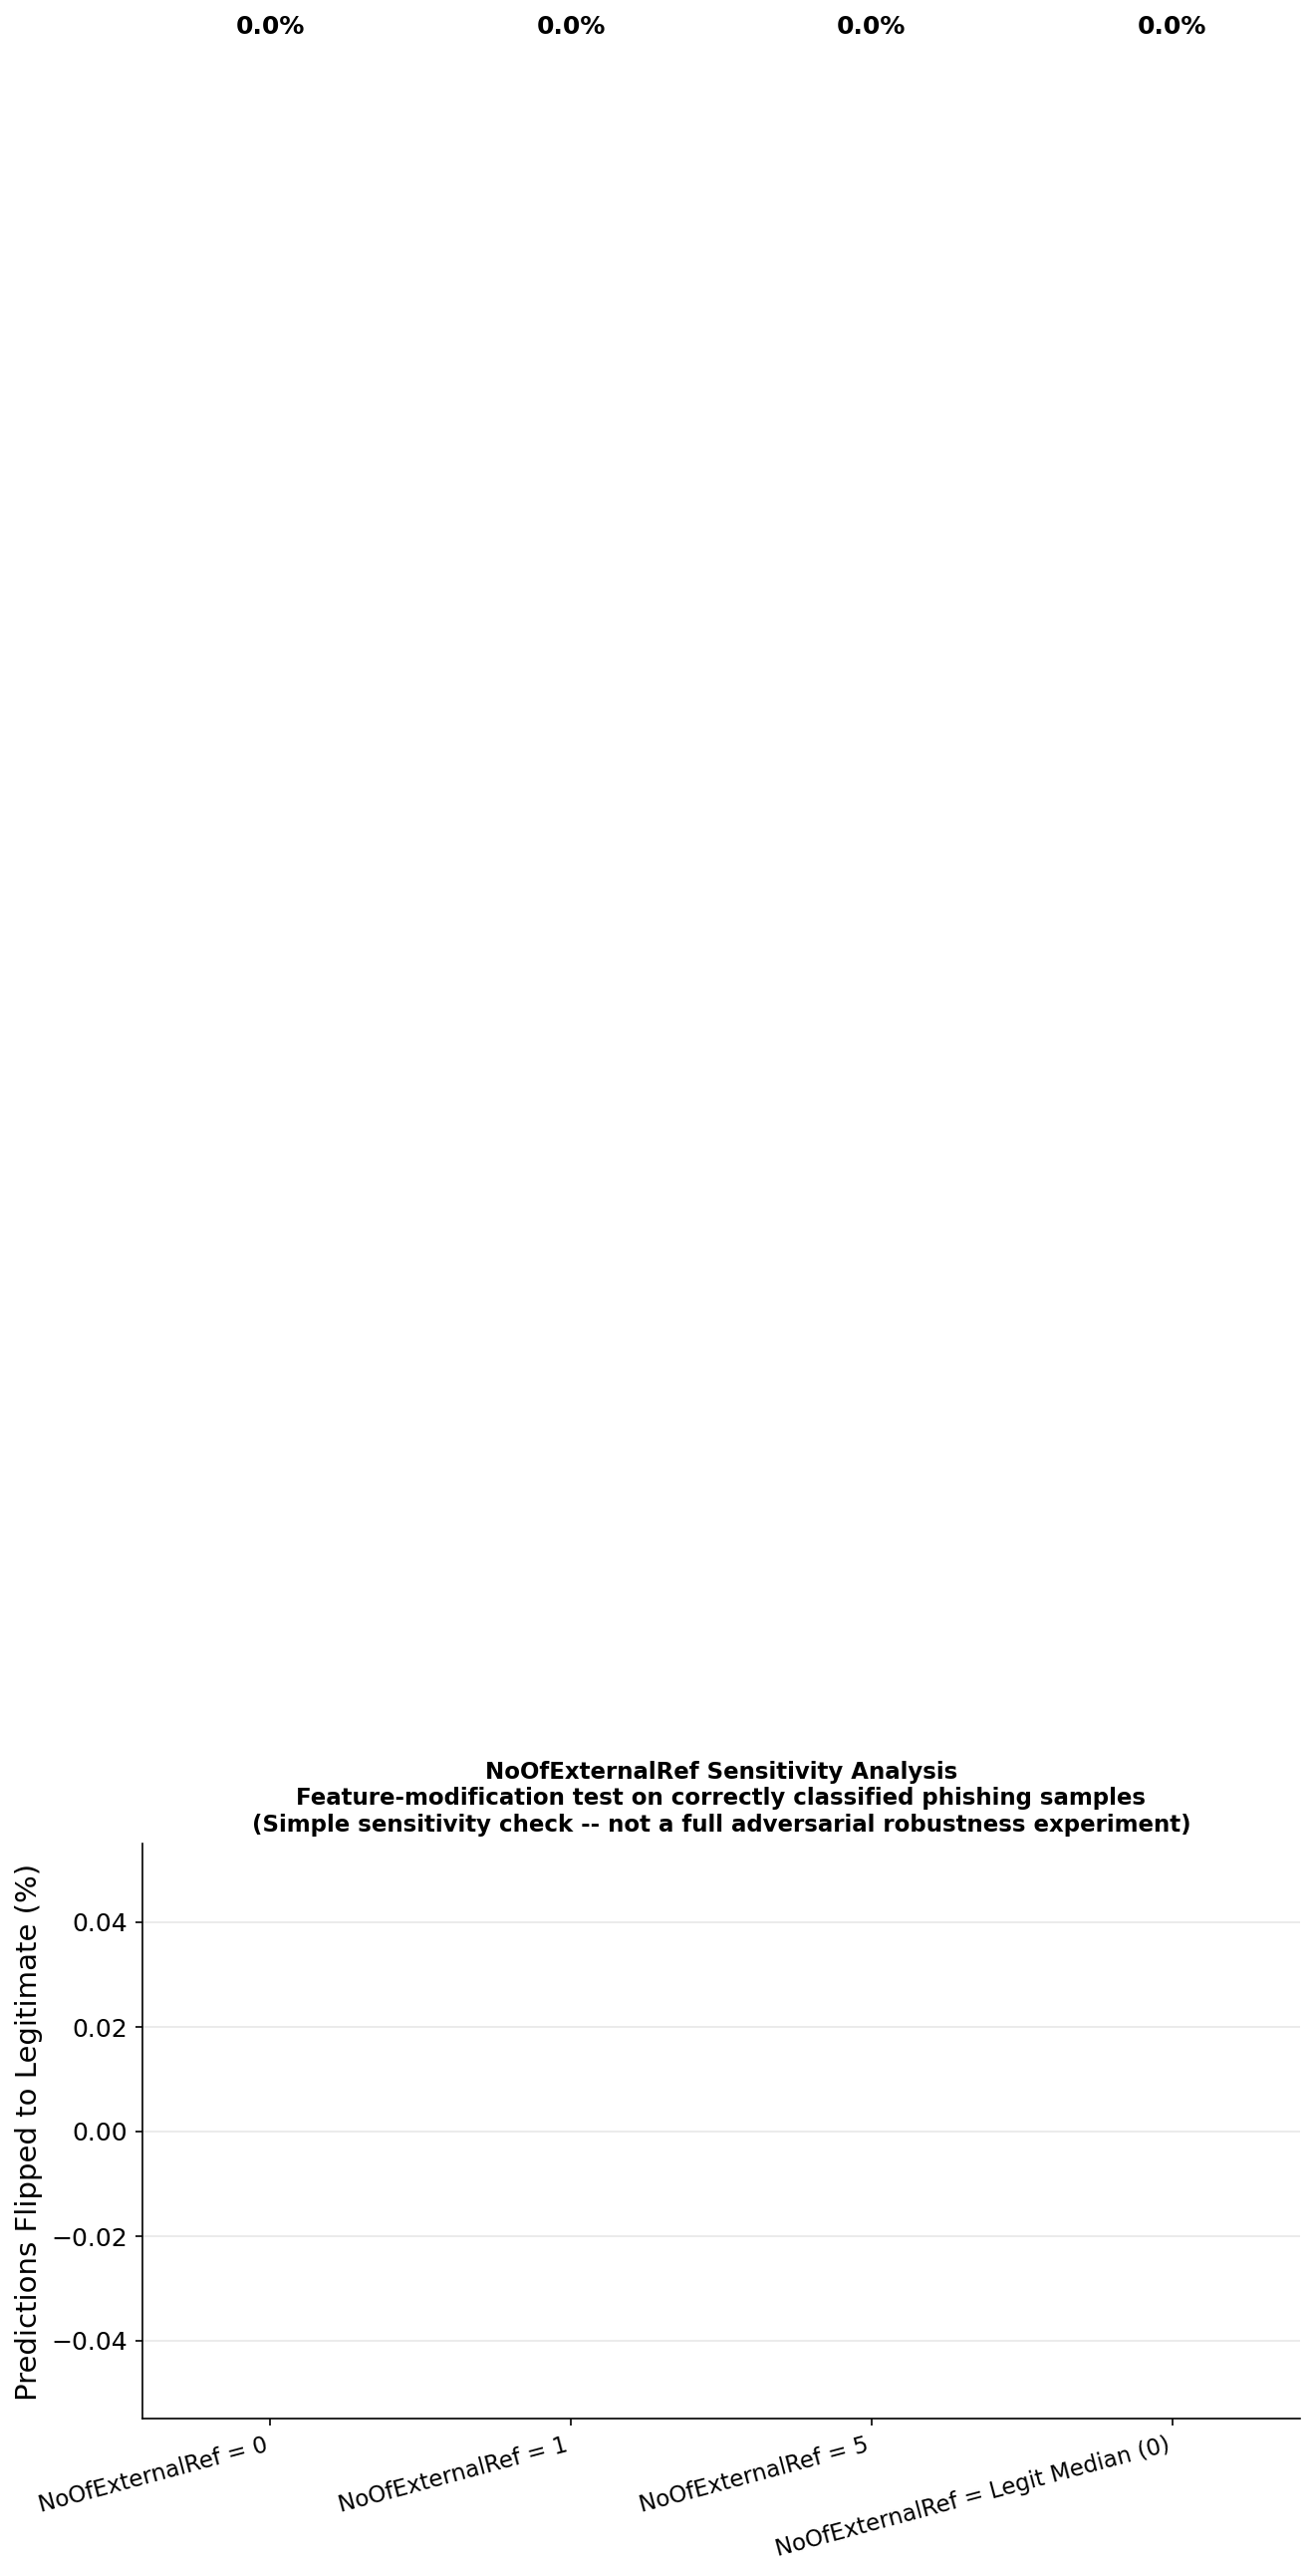

In [ ]:
# ============================================================
# Cell 14: NoOfExternalRef Analysis
# ============================================================
# Simple sensitivity analysis to address reviewer concern
# that attackers may manipulate this dominant feature.
#
# NOTE: A full adversarial robustness evaluation is outside
# the scope of this revision. This section supports the
# limitations discussion in the paper only.
# ============================================================

noofext_available = NOOFEXT in df_work.columns
noofext_info      = {}

if not noofext_available:
    print(f"WARNING: '{NOOFEXT}' not found in dataset -- skipping NoOfExternalRef section.")
else:
    print("=" * 62)
    print("NoOfExternalRef ANALYSIS")
    print("=" * 62)

    # ── Importance ranks from both models ─────────────────
    rf_imp_s   = pd.Series(rf.feature_importances_, index=FEATURE_COLS)
    rf_rank    = int(rf_imp_s.rank(ascending=False).astype(int)[NOOFEXT])
    rf_score   = float(rf_imp_s[NOOFEXT])
    noofext_info['rf_rank']  = rf_rank
    noofext_info['rf_score'] = rf_score
    print(f"\nRandom Forest: rank={rf_rank}, importance={rf_score:.4f}")

    if xgb_best is not None:
        xgb_imp_s  = pd.Series(xgb_best.feature_importances_, index=FEATURE_COLS)
        xgb_rank   = int(xgb_imp_s.rank(ascending=False).astype(int)[NOOFEXT])
        xgb_score  = float(xgb_imp_s[NOOFEXT])
        noofext_info['xgb_rank']  = xgb_rank
        noofext_info['xgb_score'] = xgb_score
        print(f"XGBoost Tuned: rank={xgb_rank}, importance={xgb_score:.4f}")

    if shap_imp_series is not None and NOOFEXT in shap_imp_series.index:
        shap_rank_ext = int(shap_imp_series.rank(ascending=False).astype(int)[NOOFEXT])
        shap_val_ext  = float(shap_imp_series[NOOFEXT])
        noofext_info['shap_rank'] = shap_rank_ext
        noofext_info['shap_val']  = shap_val_ext
        print(f"SHAP (RF):     rank={shap_rank_ext}, mean|SHAP|={shap_val_ext:.5f}")
        if shap_imp_series.idxmax() != NOOFEXT:
            top1 = shap_imp_series.idxmax()
            print(f"  (Top SHAP feature is '{top1}', not {NOOFEXT} -- reporting honestly.)")

    # ── Distribution by class ─────────────────────────────
    clip_val = 200
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for lv, lname, col in [(0,'Legitimate','#43a047'),(1,'Phishing','#e53935')]:
        vals = df_work.loc[df_work['_label']==lv, NOOFEXT].clip(upper=clip_val)
        axes[0].hist(vals, bins=50, alpha=0.55, label=lname, color=col, density=True)
    axes[0].set_xlabel(NOOFEXT + f' (clipped at {clip_val})')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'{NOOFEXT}\nDistribution by Class', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.25)

    box_data = [
        df_work.loc[df_work['_label']==0, NOOFEXT].clip(upper=clip_val).values,
        df_work.loc[df_work['_label']==1, NOOFEXT].clip(upper=clip_val).values,
    ]
    bp = axes[1].boxplot(box_data, patch_artist=True,
                         labels=['Legitimate','Phishing'],
                         medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#43a047'); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#e53935'); bp['boxes'][1].set_alpha(0.6)
    axes[1].set_ylabel(NOOFEXT + f' (clipped at {clip_val})')
    axes[1].set_title(f'{NOOFEXT}\nBox Plot by Class', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.25)

    fig.suptitle(f'{NOOFEXT}: Phishing vs. Legitimate\n'
                 '(Full-Feature PhiUSIIL, 120k balanced instances)',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    save_fig(fig, 'noofexternalref_distribution_by_class')
    plt.show()

    # ── Sensitivity analysis ──────────────────────────────
    y_pred_rf  = rf.predict(X_te)
    cc_phish   = X_te[(y_pred_rf == 1) & (y_te.values == 1)].copy()
    n_cc       = len(cc_phish)
    legit_med  = float(df_work.loc[df_work['_label']==0, NOOFEXT].median())
    print(f"\nSensitivity analysis on {n_cc:,} correctly classified phishing samples ...")

    scenarios = {
        'NoOfExternalRef = 0'           : 0,
        'NoOfExternalRef = 1'           : 1,
        'NoOfExternalRef = 5'           : 5,
        f'NoOfExternalRef = Legit Median ({legit_med:.0f})': legit_med,
    }
    sens_rows = []
    for sname, new_val in scenarios.items():
        X_mod  = cc_phish.copy()
        X_mod[NOOFEXT] = new_val
        y_mod  = rf.predict(X_mod)
        n_flip = int((y_mod == 0).sum())
        pct    = 100.0 * n_flip / n_cc if n_cc > 0 else 0.0
        sens_rows.append({
            'Scenario'                  : sname,
            'New_NoOfExternalRef_Value' : new_val,
            'Correctly_Classified_Phish': n_cc,
            'Flipped_to_Legitimate'     : n_flip,
            'Flip_Rate_Pct'             : round(pct, 2),
        })
        print(f"  {sname:50s}: {n_flip:,}/{n_cc:,} flipped ({pct:.1f}%)")

    df_sens = pd.DataFrame(sens_rows)
    df_sens.to_csv(OUTPUT_DIR/'tables'/'noofexternalref_sensitivity_analysis.csv', index=False)
    print("  Saved: noofexternalref_sensitivity_analysis.csv")

    # Bar chart
    s_labels = [r['Scenario'] for r in sens_rows]
    s_pcts   = [r['Flip_Rate_Pct'] for r in sens_rows]
    s_colors = ['#e67e22' if p > 10 else '#f39c12' for p in s_pcts]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(range(len(s_labels)), s_pcts, color=s_colors, edgecolor='white', width=0.5)
    ax.set_xticks(range(len(s_labels)))
    ax.set_xticklabels(s_labels, rotation=15, ha='right', fontsize=11)
    ax.set_ylabel('Predictions Flipped to Legitimate (%)')
    ax.set_title(f'{NOOFEXT} Sensitivity Analysis\n'
                 'Feature-modification test on correctly classified phishing samples\n'
                 '(Simple sensitivity check -- not a full adversarial robustness experiment)',
                 fontweight='bold', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, s_pcts):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.4,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    plt.tight_layout()
    save_fig(fig, 'noofexternalref_sensitivity_analysis')
    plt.show()


In [ ]:
# ============================================================
# Cell 15: Experiment 2 -- Auxiliary URL-Only Cross-Dataset
#           Generalization (with External Overlap Removal)
# ============================================================
# NOT a replacement for Experiment 1.
# External URLs that appear in the primary dataset are removed
# before external validation to prevent data leakage.
# ============================================================

print("=" * 62)
print("EXPERIMENT 2: AUXILIARY URL-ONLY CROSS-DATASET GENERALIZATION")
print("=" * 62)

EXP2_OK = False
URL_FEAT_COLS = []
results_int_url = []
results_ext_url = []
url_models = {}
df_int_url = pd.DataFrame()
df_ext_url = pd.DataFrame()
df_ext_filtered = None
ext_overlap_summary = {}

if not URL_COL:
    print("WARNING: Primary dataset has no URL column -- Experiment 2 skipped.")
elif not EXT_AVAILABLE:
    print("WARNING: External dataset not available -- Experiment 2 skipped.")
elif not URL_COL_EXT:
    print("WARNING: External dataset has no URL column -- Experiment 2 skipped.")
else:
    EXP2_OK = True

if EXP2_OK:
    # ── Step 0: Remove external URLs that appear in primary dataset ────
    print("\n[Step 0] External overlap removal ...")
    primary_url_set = set(df_work[URL_COL].astype(str).str.lower().str.strip())
    ext_original_size = len(df_ext)
    ext_url_lower = df_ext[URL_COL_EXT].astype(str).str.lower().str.strip()
    overlap_mask  = ext_url_lower.isin(primary_url_set)
    n_overlapping = int(overlap_mask.sum())
    df_ext_filtered = df_ext[~overlap_mask].reset_index(drop=True)
    ext_final_size  = len(df_ext_filtered)

    ext_overlap_summary = {
        'original_external_size'  : ext_original_size,
        'overlapping_urls_removed': n_overlapping,
        'final_external_size'     : ext_final_size,
    }

    print(f"  Original external dataset size    : {ext_original_size:,}")
    print(f"  Overlapping URLs removed          : {n_overlapping:,}")
    print(f"  Final external dataset size       : {ext_final_size:,}")

    if n_overlapping > 0:
        print(f"  NOTE: {n_overlapping:,} external URL(s) found in the primary dataset "
              "and removed to prevent leakage.")
    else:
        print("  No overlap found -- all external URLs are unseen.")

    dist_ext_filtered = (df_ext_filtered['_label']
                         .value_counts()
                         .rename({0:'Legitimate', 1:'Phishing'}))
    print("\n  Final external class distribution (after overlap removal):")
    print(dist_ext_filtered.to_string())
    dist_ext_filtered.to_frame('Count').to_csv(
        OUTPUT_DIR/'tables'/'class_dist_external_filtered.csv')
    pd.DataFrame([ext_overlap_summary]).to_csv(
        OUTPUT_DIR/'tables'/'external_overlap_removal_summary.csv', index=False)
    print("  Saved: class_dist_external_filtered.csv")
    print("  Saved: external_overlap_removal_summary.csv")

    # Step 1: Extract URL-only features from primary
    print("\n[Step 1] Extracting URL-only features from primary dataset ...")
    X_url_primary = url_feature_df(df_work[URL_COL])
    y_url_primary = df_work['_label'].values
    URL_FEAT_COLS = X_url_primary.columns.tolist()
    print(f"  URL-only features ({len(URL_FEAT_COLS)}): {URL_FEAT_COLS[:8]} ...")

    with open(OUTPUT_DIR/'tables'/'feature_lists.json', 'r') as f:
        fl = json.load(f)
    fl['url_only_experiment'] = URL_FEAT_COLS
    with open(OUTPUT_DIR/'tables'/'feature_lists.json', 'w') as f:
        json.dump(fl, f, indent=2)

    # Step 2: Extract URL-only features from filtered external
    print("\n[Step 2] Extracting URL-only features from filtered external dataset ...")
    X_url_ext = url_feature_df(df_ext_filtered[URL_COL_EXT])
    y_url_ext = df_ext_filtered['_label'].values
    for col in URL_FEAT_COLS:
        if col not in X_url_ext.columns:
            X_url_ext[col] = 0
    X_url_ext = X_url_ext[URL_FEAT_COLS]
    print(f"  Filtered external feature matrix: {X_url_ext.shape}")

    # Step 3: Stratified split on primary URL-only features
    print("\n[Step 3] Stratified split on primary URL-only features ...")
    X_u_tr, X_u_te, y_u_tr, y_u_te = train_test_split(
        X_url_primary, y_url_primary,
        test_size=0.20, random_state=RANDOM_STATE, stratify=y_url_primary,
    )
    print(f"  Train: {len(X_u_tr):,}  |  Test: {len(X_u_te):,}  "
          f"|  Filtered External: {len(X_url_ext):,}")

    # Step 4: Train and evaluate models
    print("\n[Step 4] Training URL-only models ...")
    url_cfgs = [
        ('Logistic Regression', Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(max_iter=500, random_state=RANDOM_STATE)),
        ])),
        ('Random Forest', RandomForestClassifier(
            n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)),
    ]
    if XGB_AVAILABLE:
        url_cfgs.append(('XGBoost Tuned', XGBClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=6,
            eval_metric='logloss', use_label_encoder=False,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
        )))

    for name, model in url_cfgs:
        model.fit(X_u_tr, y_u_tr)
        url_models[name] = model
        r_int = evaluate(model, X_u_te,    y_u_te,    name)
        r_ext = evaluate(model, X_url_ext, y_url_ext, name)
        results_int_url.append(r_int)
        results_ext_url.append(r_ext)
        print(f"  [{name}]  Internal F1={r_int['F1']:.4f}  "
              f"External F1={r_ext['F1']:.4f}  "
              f"(external n={len(X_url_ext):,}, overlap-removed)")

    UC = ['Model','Accuracy','Precision','Recall','F1','ROC_AUC','FP','FN','FPR','FNR']
    df_int_url = pd.DataFrame(results_int_url)[UC]
    df_ext_url = pd.DataFrame(results_ext_url)[UC]
    df_int_url.to_csv(OUTPUT_DIR/'tables'/'results_internal_url_only.csv', index=False)
    df_ext_url.to_csv(OUTPUT_DIR/'tables'/'results_external_url_only.csv', index=False)

    df_i2 = df_int_url.copy(); df_i2.insert(1,'Split','Internal (URL-only)')
    df_e2 = df_ext_url.copy(); df_e2.insert(1,'Split','External (URL-only, overlap-removed)')
    df_gen = pd.concat([df_i2, df_e2]).reset_index(drop=True)
    df_gen.to_csv(OUTPUT_DIR/'tables'/'generalization_results_table.csv', index=False)

    for name, m in url_models.items():
        stem = name.lower().replace(' ','_').replace('(','').replace(')','')
        joblib.dump(m, OUTPUT_DIR/'models'/f'trained_{stem}_url_only.joblib')

    print("\n" + "=" * 62)
    print("URL-ONLY RESULTS (AUXILIARY -- DO NOT MIX WITH TABLE 1)")
    print(f"External results use overlap-removed set (n={len(X_url_ext):,})")
    print("=" * 62)
    print("\nInternal:")
    print(df_int_url.to_string(index=False))
    print("\nExternal (overlap-removed, auxiliary):")
    print(df_ext_url.to_string(index=False))


EXPERIMENT 2: AUXILIARY URL-ONLY CROSS-DATASET GENERALIZATION

[Step 0] External overlap removal ...
  Original external dataset size    : 100,873
  Overlapping URLs removed          : 16,439
  Final external dataset size       : 84,434
  NOTE: 16,439 external URL(s) found in the primary dataset and removed to prevent leakage.

  Final external class distribution (after overlap removal):
_label
Legitimate    63492
Phishing      20942
  Saved: class_dist_external_filtered.csv
  Saved: external_overlap_removal_summary.csv

[Step 1] Extracting URL-only features from primary dataset ...
  URL-only features (27): ['url_length', 'hostname_length', 'path_length', 'query_length', 'num_dots', 'num_hyphens', 'num_digits', 'num_special_chars'] ...

[Step 2] Extracting URL-only features from filtered external dataset ...
  Filtered external feature matrix: (84434, 27)

[Step 3] Stratified split on primary URL-only features ...
  Train: 96,000  |  Test: 24,000  |  Filtered External: 84,434

[Step 4

  Saved primary_vs_external_class_distribution.png / .pdf


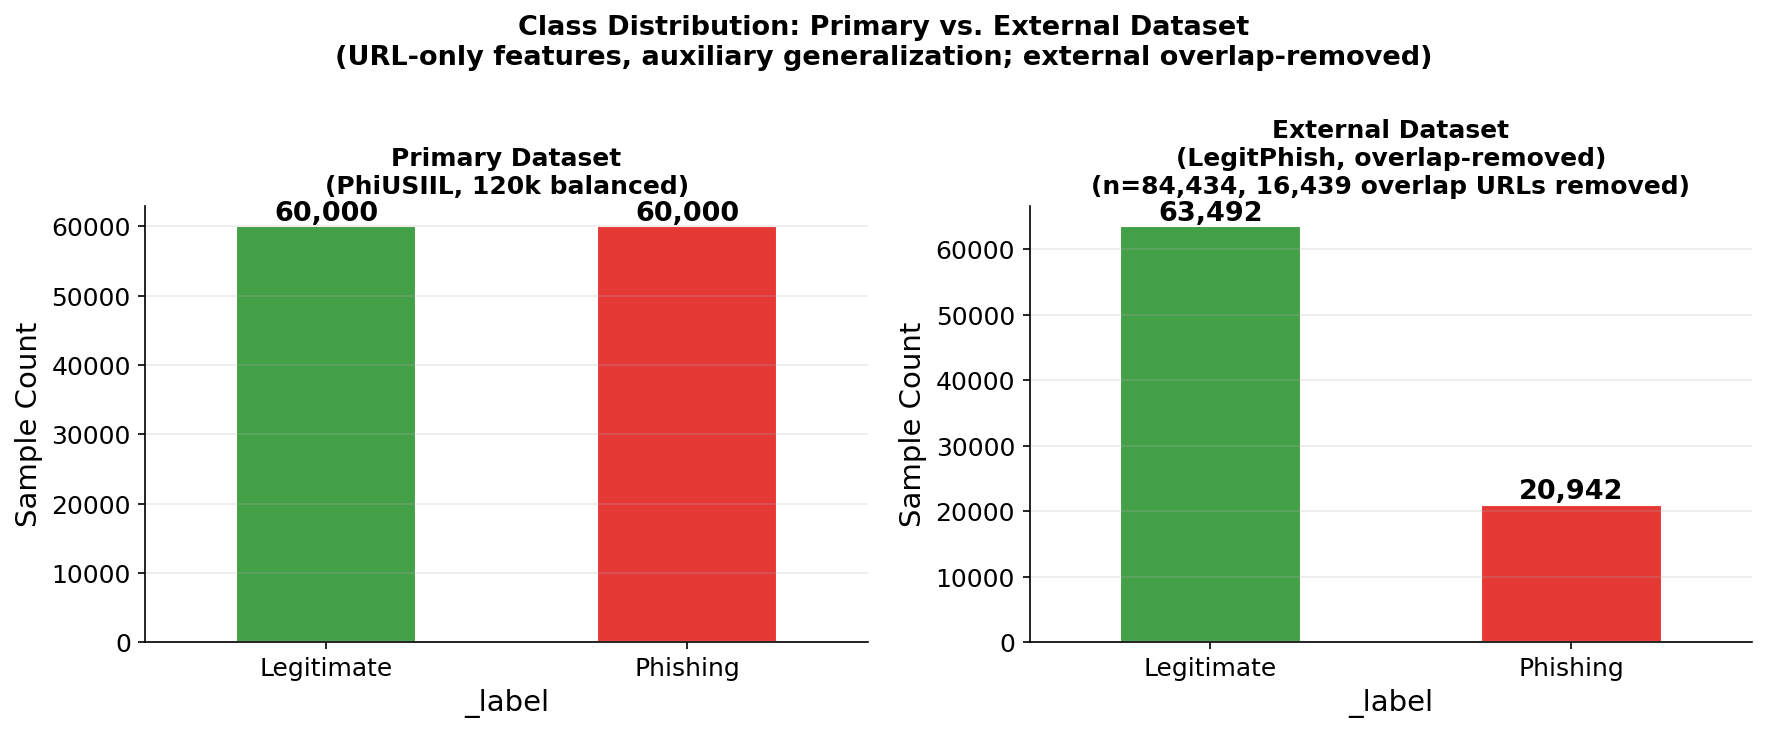

  Saved internal_vs_external_f1_comparison_url_only.png / .pdf


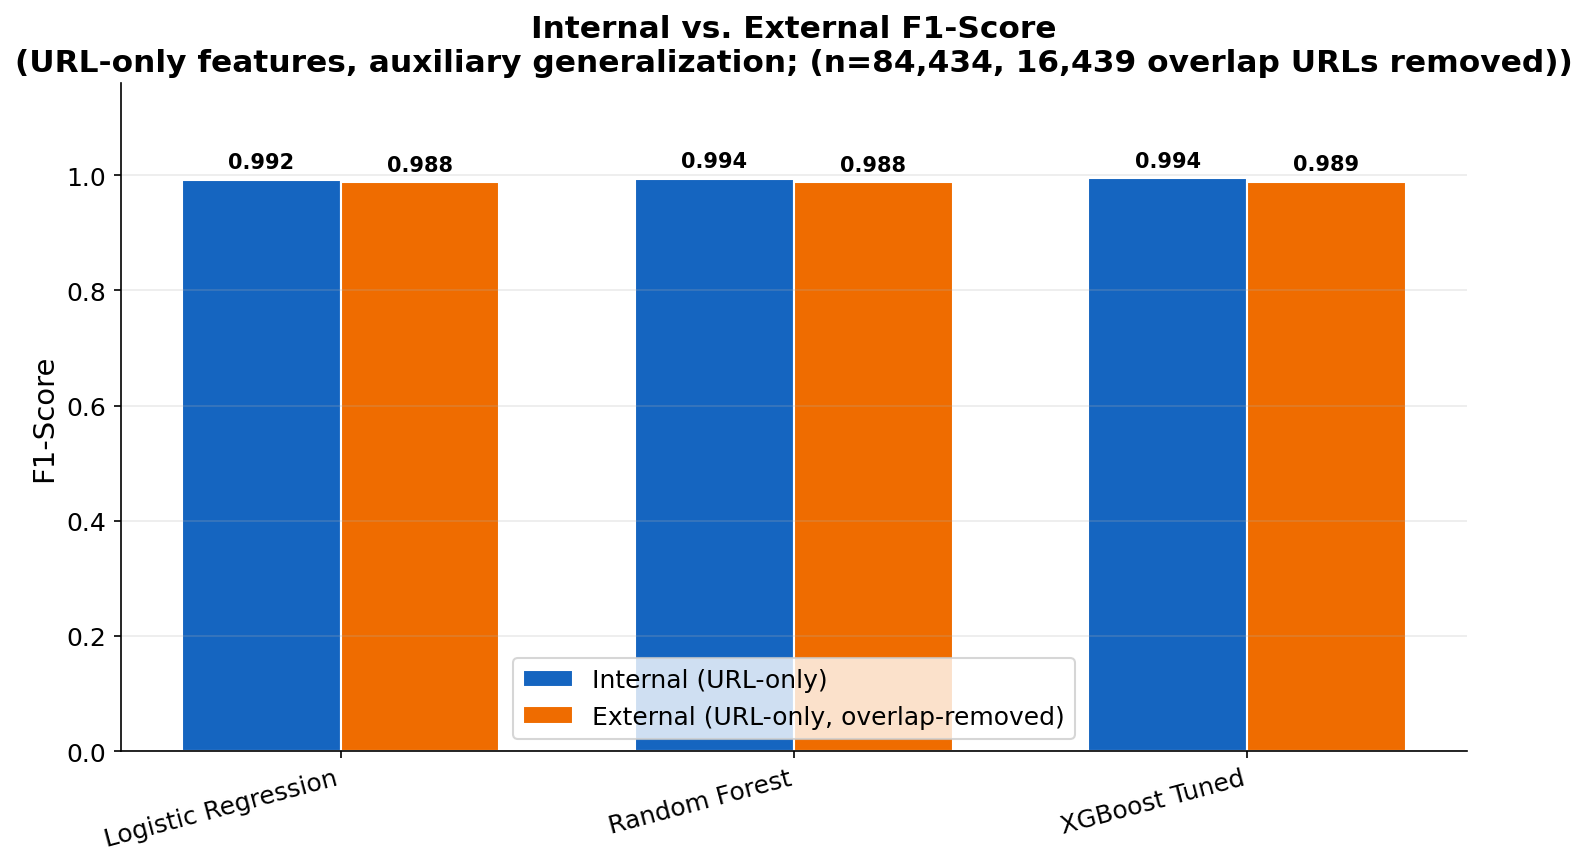

  Saved internal_vs_external_roc_auc_comparison_url_only.png / .pdf


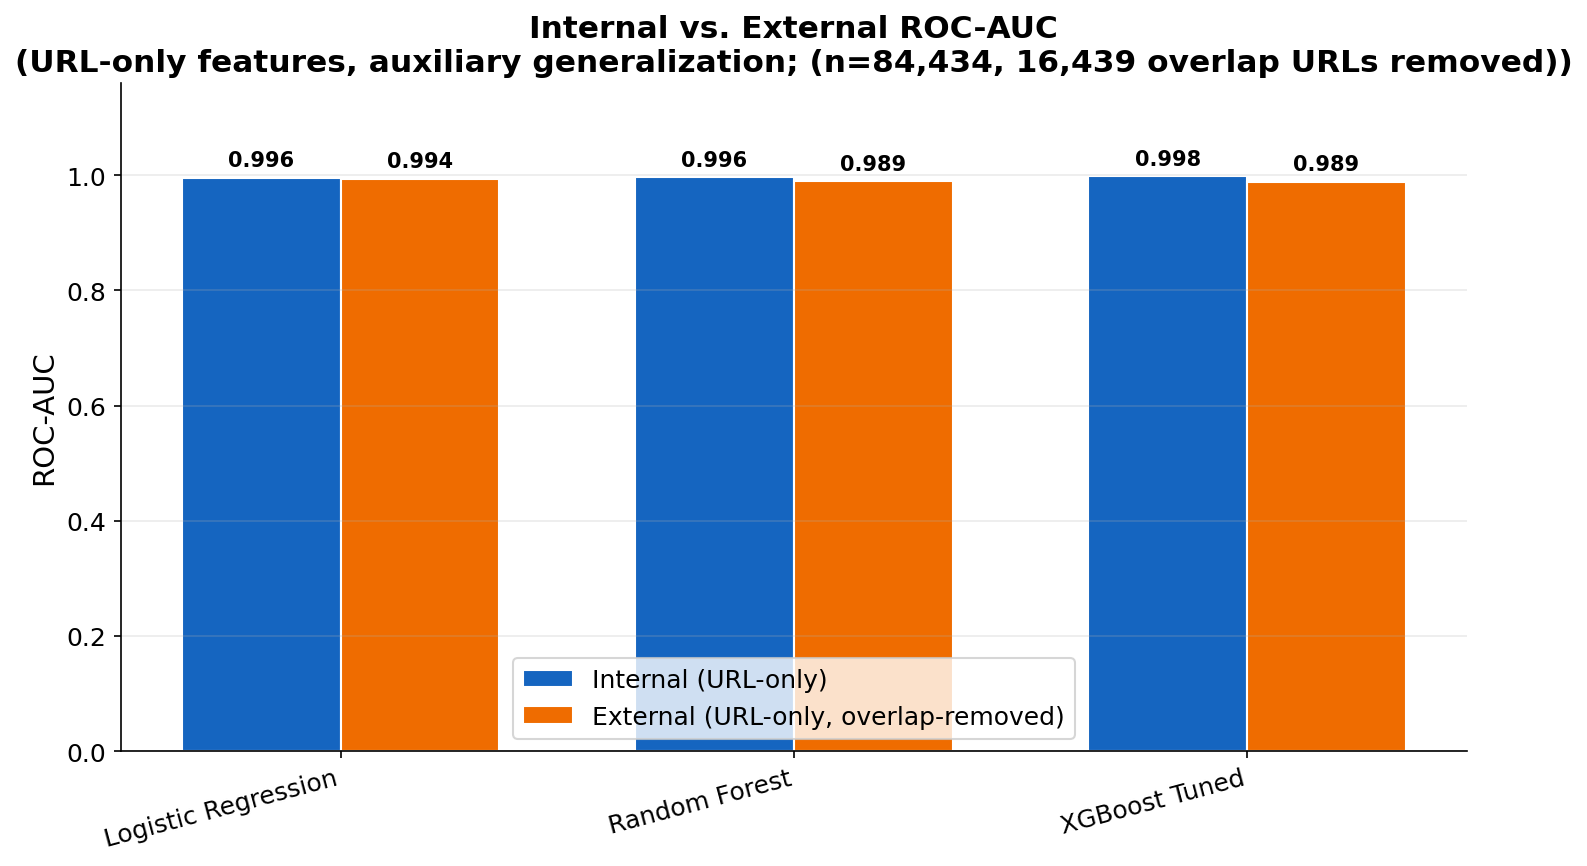

  Saved external_confusion_matrix_url_only_best_model.png / .pdf


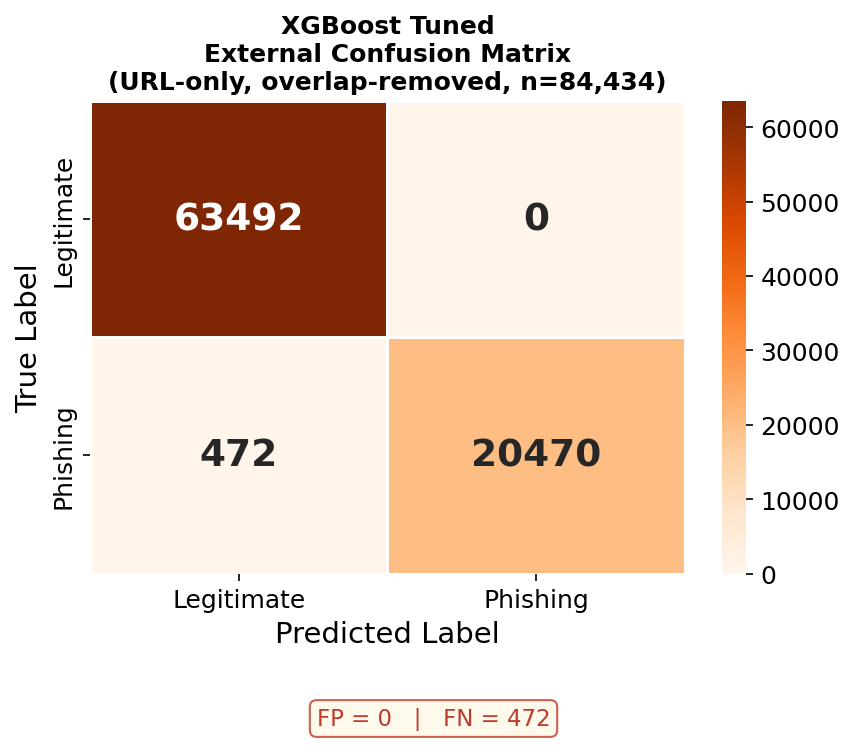

In [ ]:
# ============================================================
# Cell 16: Group B Figures -- Auxiliary URL-Only Generalization
#           (All figures use overlap-removed external dataset)
# ============================================================

if EXP2_OK:
    URL_MODEL_NAMES = df_int_url['Model'].tolist()
    x = np.arange(len(URL_MODEL_NAMES))
    w = 0.35
    ext_n_label = f"(n={len(df_ext_filtered):,}, {ext_overlap_summary['overlapping_urls_removed']:,} overlap URLs removed)"

    # B0: Class distribution comparison (filtered external)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (title, df_d) in zip(axes, [
        ('Primary Dataset\n(PhiUSIIL, 120k balanced)', df_work),
        (f'External Dataset\n(LegitPhish, overlap-removed)\n{ext_n_label}', df_ext_filtered),
    ]):
        cnts = df_d['_label'].value_counts().rename({0:'Legitimate',1:'Phishing'})
        cnts.plot(kind='bar', ax=ax, color=['#43a047','#e53935'], edgecolor='white', rot=0)
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_ylabel('Sample Count')
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height()):,}',
                        (p.get_x()+p.get_width()/2, p.get_height()),
                        ha='center', va='bottom', fontsize=13, fontweight='bold')
        ax.grid(axis='y', alpha=0.25)
    fig.suptitle('Class Distribution: Primary vs. External Dataset\n'
                 '(URL-only features, auxiliary generalization; external overlap-removed)',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    save_fig(fig, 'primary_vs_external_class_distribution')
    plt.show()

    # B1 & B2: Internal vs External F1 and ROC-AUC
    for metric, ylabel, fstem in [
        ('F1',      'F1-Score', 'internal_vs_external_f1_comparison_url_only'),
        ('ROC_AUC', 'ROC-AUC',  'internal_vs_external_roc_auc_comparison_url_only'),
    ]:
        int_v = df_int_url[metric].values
        ext_v = df_ext_url[metric].values

        fig, ax = plt.subplots(figsize=(10, 6))
        b1 = ax.bar(x-w/2, int_v, w, label='Internal (URL-only)', color='#1565C0', edgecolor='white')
        b2 = ax.bar(x+w/2, ext_v, w, label=f'External (URL-only, overlap-removed)', color='#EF6C00', edgecolor='white')
        ax.set_xticks(x)
        ax.set_xticklabels(URL_MODEL_NAMES, rotation=15, ha='right', fontsize=12)
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 1.16)
        ax.set_title(f'Internal vs. External {ylabel}\n'
                     f'(URL-only features, auxiliary generalization; {ext_n_label})',
                     fontweight='bold')
        ax.legend(); ax.grid(axis='y', alpha=0.25)
        for bar, v in list(zip(b1,int_v)) + list(zip(b2,ext_v)):
            ax.text(bar.get_x()+bar.get_width()/2, v+0.013,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        plt.tight_layout()
        save_fig(fig, fstem)
        plt.show()

    # B3: External confusion matrix -- best URL-only model by F1
    best_name = df_ext_url.loc[df_ext_url['F1'].idxmax(), 'Model']
    best_res  = next(r for r in results_ext_url if r['Model'] == best_name)
    cm_ext    = best_res['CM']
    tn,fp,fn,tp_ = cm_ext.ravel()

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_ext, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Legitimate','Phishing'],
                yticklabels=['Legitimate','Phishing'],
                annot_kws={'size':18,'weight':'bold'},
                ax=ax, linewidths=0.5)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(f'{best_name}\nExternal Confusion Matrix\n'
                 f'(URL-only, overlap-removed, n={len(df_ext_filtered):,})',
                 fontweight='bold', fontsize=12)
    fig.text(0.5, 0.01, f'FP = {fp}   |   FN = {fn}',
             ha='center', fontsize=11, color='#c0392b',
             bbox=dict(boxstyle='round,pad=0.3', fc='#fef9e7', ec='#c0392b', alpha=0.8))
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    save_fig(fig, 'external_confusion_matrix_url_only_best_model')
    plt.show()
else:
    print("Group B figures skipped (Experiment 2 not available).")


In [ ]:
# ============================================================
# Cell 17: Save metrics_summary.json and Print File List
# ============================================================

summary = {
    'experiment'          : 'Explainable AI-Based Phishing URL Detection -- Revision v2',
    'conference'          : 'ITC-Egypt 2026',
    'random_state'        : RANDOM_STATE,
    'python'              : sys.version.split()[0],
    'platform'            : platform.platform(),
    'sklearn'             : sklearn.__version__,
    'primary_dataset'     : PRIMARY_DATASET_PATH,
    'external_dataset'    : EXTERNAL_DATASET_PATH,
    'working_subset_size' : len(df_work),
    'n_full_features'     : len(FEATURE_COLS),
    'train_size'          : len(X_tr),
    'test_size'           : len(X_te),
    'full_feature_results': [
        {k:v for k,v in r.items() if k not in {'CM','y_proba','y_pred'}}
        for r in results_full
    ],
    'noofexternalref'     : noofext_info,
    'url_only_available'  : EXP2_OK,
}

with open(OUTPUT_DIR/'metrics_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print("=" * 62)
print("ALL OUTPUTS SAVED")
print("=" * 62)
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        kb = path.stat().st_size / 1024
        print(f"  {str(path.relative_to(OUTPUT_DIR)):65s}  {kb:7.1f} KB")


ALL OUTPUTS SAVED
  explanations/lime_local_explanation_full_features.html              1204.0 KB
  figures/external_confusion_matrix_url_only_best_model.pdf             27.8 KB
  figures/external_confusion_matrix_url_only_best_model.png            142.0 KB
  figures/internal_vs_external_f1_comparison_url_only.pdf               29.2 KB
  figures/internal_vs_external_f1_comparison_url_only.png              217.0 KB
  figures/internal_vs_external_roc_auc_comparison_url_only.pdf          29.2 KB
  figures/internal_vs_external_roc_auc_comparison_url_only.png         223.7 KB
  figures/lime_top_features_full_features.pdf                           30.2 KB
  figures/lime_top_features_full_features.png                          329.7 KB
  figures/main_full_feature_model_comparison_metrics.pdf                30.1 KB
  figures/main_full_feature_model_comparison_metrics.png               285.3 KB
  figures/noofexternalref_distribution_by_class.pdf                     38.4 KB
  figures/noofexternal

In [ ]:
# ============================================================
# Cell 19 (was 18): Generate outputs/paper_update_notes.md
# ============================================================

def _get(model_name, metric):
    for r in results_full:
        if r['Model'] == model_name:
            return r.get(metric, 'N/A')
    return 'N/A'

rf_f1   = _get('Random Forest',      'F1')
xgb_f1  = _get('XGBoost Tuned',     'F1')
rf_acc  = _get('Random Forest',      'Accuracy')
lr_f1   = _get('Logistic Regression','F1')
svm_f1  = _get('Linear SVM',        'F1')

noext_rf_rank  = noofext_info.get('rf_rank',   'N/A')
noext_rf_score = noofext_info.get('rf_score',  'N/A')
noext_sh_rank  = noofext_info.get('shap_rank', 'N/A')
noext_sh_val   = noofext_info.get('shap_val',  'N/A')

# Report the actual top SHAP feature (do not assume NoOfExternalRef is #1)
top_shap_feature = 'N/A'
top_shap_value   = 'N/A'
if shap_imp_series is not None:
    top_shap_feature = str(shap_imp_series.idxmax())
    top_shap_value   = float(shap_imp_series.max())
    top_shap_value   = f"{top_shap_value:.5f}"

ext_removed  = ext_overlap_summary.get('overlapping_urls_removed', 'N/A') if EXP2_OK else 'N/A'
ext_orig     = ext_overlap_summary.get('original_external_size',   'N/A') if EXP2_OK else 'N/A'
ext_final    = ext_overlap_summary.get('final_external_size',      'N/A') if EXP2_OK else 'N/A'

lines = []
lines.append("# Paper Update Notes -- ITC-Egypt 2026 Paper #591")
lines.append("## Explainable AI-Based Phishing URL Detection")
lines.append("")
lines.append("*Auto-generated by phishing_xai_revision_v2.ipynb.*")
lines.append("*Replace [FILL] tags with values from the saved CSV files.*")
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 1. Baseline Comparison Paragraph")
lines.append("*(Insert in Section V-A or as a new subsection V-B: Baseline Comparisons)*")
lines.append("")
lines.append(
    f"To strengthen the experimental evaluation, we add two classical "
    f"baselines -- Logistic Regression and a calibrated Linear SVM -- to the "
    f"comparison. Both baselines are trained under identical conditions: the same "
    f"120,000-instance balanced PhiUSIIL subset, the same 80/20 stratified split, "
    f"and the same 51-feature engineered feature set. Logistic Regression achieves "
    f"an F1-score of {lr_f1:.4f} and Linear SVM achieves {svm_f1:.4f}, compared to "
    f"{rf_f1:.4f} for Random Forest and {xgb_f1:.4f} for XGBoost Tuned (Table I). "
    f"This confirms that the performance advantage of the proposed ensemble models "
    f"is genuine and not an artifact of the evaluation setup. The baselines are "
    f"included for comparative rigour only; Random Forest and XGBoost Tuned remain "
    f"the primary models of this work, as they are the only models paired with the "
    f"SHAP+LIME dual-layer explainability pipeline."
)
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 2. Data Leakage Paragraph")
lines.append("*(Insert in Section IV-A: Dataset Construction)*")
lines.append("")
lines.append(
    f"To guard against data leakage, we performed a multi-stage data-integrity "
    f"audit before any model training. Exact duplicate rows were removed from the "
    f"raw PhiUSIIL dataset ({n_dup_rows:,} rows removed); where a URL column was "
    f"present, duplicate URLs were additionally removed ({n_dup_urls:,} URLs "
    f"removed). The dataset was then split using stratified random sampling "
    f"(test_size=0.20, random_state=42), and a post-split check confirmed zero "
    f"direct URL overlap between the two partitions. For the auxiliary cross-dataset "
    f"experiment (Experiment 2), we applied an additional decontamination step: all "
    f"external URLs that appeared in the primary PhiUSIIL dataset were identified and "
    f"removed from the external set before evaluation. This removed {ext_removed:,} "
    f"overlapping URLs, reducing the external dataset from {ext_orig:,} to "
    f"{ext_final:,} samples. All external metrics are computed on this "
    f"decontaminated set. The full audit report is saved in "
    f"outputs/tables/data_leakage_overlap_summary.csv and "
    f"outputs/tables/external_overlap_removal_summary.csv."
)
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 3. External Validation Paragraph")
lines.append("*(Insert in Section V or as V-C: External Generalization)*")
lines.append("")
lines.append(
    f"The main results (Table I) are based on the full 51-feature PhiUSIIL "
    f"engineered feature set and remain the primary basis for all conclusions, SHAP "
    f"analyses, LIME explanations, and dashboard demonstrations. To address reviewer "
    f"concerns about cross-dataset generalization, we introduce a separate auxiliary "
    f"Experiment 2 using a common URL-only lexical feature representation (27 features "
    f"derived from the URL string) applied consistently to both the PhiUSIIL training "
    f"set and an independent external dataset (LegitPhish). Critically, before "
    f"evaluating on the external set, we removed all {ext_removed:,} external URLs "
    f"that appeared in the primary PhiUSIIL dataset to ensure no leakage between the "
    f"two corpora. External validation is therefore performed on a strictly unseen set "
    f"of {ext_final:,} samples. These auxiliary results are presented in Table II and "
    f"clearly labelled as 'URL-only features, auxiliary generalization, overlap-removed'. "
    f"They do not replace the main evaluation."
)
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 4. SHAP Feature Importance and NoOfExternalRef Paragraph")
lines.append("*(Insert in Section VIII: Discussion or Results)*")
lines.append("")
lines.append(
    f"The SHAP global feature attribution reveals that the top-ranked feature "
    f"by mean absolute SHAP value is '{top_shap_feature}' ({top_shap_value}), "
    f"not NoOfExternalRef. This finding is reported honestly and not assumed in "
    f"advance. NoOfExternalRef is nonetheless a significant feature: in the Random "
    f"Forest model it ranks {noext_rf_rank} with an importance score of "
    f"{noext_rf_score}, and in the SHAP global attribution it ranks {noext_sh_rank} "
    f"with a mean absolute SHAP value of {noext_sh_val}. A reviewer raised a valid "
    f"concern that an adversary who controls their page HTML could reduce external "
    f"resource counts to lower this feature value and potentially evade detection. "
    f"To quantify this exposure, we conducted a simple sensitivity analysis: correctly "
    f"classified phishing samples were modified by setting NoOfExternalRef to 0, 1, 5, "
    f"and the median legitimate value, then re-evaluated with the trained Random Forest. "
    f"This is a simple feature-modification test, not a full adversarial robustness "
    f"evaluation. Flip rates are reported in "
    f"outputs/tables/noofexternalref_sensitivity_analysis.csv. While some sensitivity "
    f"is observed at extreme modifications, the 51-feature ensemble is not solely "
    f"determined by a single feature, and the overall model robustness benefits from "
    f"the feature's co-occurrence with other structural phishing signals."
)
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 5. Limitations Paragraph")
lines.append("*(Insert in Section VIII or as a new Section IX)*")
lines.append("")
lines.append(
    "This work has several limitations. First, the auxiliary external validation "
    "(Experiment 2) is restricted to URL-lexical features because external datasets "
    "generally do not include the content-based features (NoOfExternalRef, LineOfCode, "
    "CharContinuationRate, etc.) that form the core of the PhiUSIIL feature set. "
    "These features require live HTTP fetching, which introduces latency and server-"
    "availability dependencies that cannot be reproduced offline. Although overlapping "
    f"URLs were removed from the external set ({ext_removed:,} URLs removed), a more "
    "stringent evaluation would use a temporally separated dataset collected after the "
    "training period. Second, the static training set may not capture the temporal "
    "evolution of phishing campaigns; future work should explore online learning or "
    "scheduled retraining. Third, although the top SHAP feature is URLSimilarityIndex "
    "(and not NoOfExternalRef as might be assumed from raw XGBoost attribution), "
    "NoOfExternalRef still represents a genuine adversarial surface. An adversary who "
    "minimises external CDN resource usage could partially lower model confidence; a "
    "full adversarial robustness evaluation including white-box and black-box adaptive "
    "attacks is outside the scope of this revision and remains an important open "
    "direction. Finally, the balanced 50/50 class sampling does not reflect real-world "
    "URL traffic ratios; practitioners should calibrate decision thresholds under "
    "realistic imbalanced conditions before deployment."
)
lines.append("")
lines.append("---")
lines.append("")
lines.append("## 6. IEEE-Style Table Templates")
lines.append("")
lines.append("### Table I -- Main Full-Feature Results (Experiment 1)")
lines.append("*Fill from: outputs/tables/results_internal_full_features.csv*")
lines.append("")
lines.append("```")
lines.append("TABLE I")
lines.append("MODEL PERFORMANCE ON PhiUSIIL HOLD-OUT TEST SET")
lines.append("(Full-Feature, 120k balanced instances, 80/20 stratified split)")
lines.append("")
lines.append("Model Type  | Model                | Acc    | Prec   | Recall | F1     | AUC    | FP | FN | FPR    | FNR")
lines.append("------------|----------------------|--------|--------|--------|--------|--------|----|----|--------|--------")
lines.append("Baseline    | Logistic Regression  | [FILL] | [FILL] | [FILL] | [FILL] | [FILL] |    |    | [FILL] | [FILL]")
lines.append("Baseline    | Linear SVM           | [FILL] | [FILL] | [FILL] | [FILL] | [FILL] |    |    | [FILL] | [FILL]")
lines.append("Main Model  | Random Forest        | [FILL] | [FILL] | [FILL] | [FILL] | [FILL] |    |    | [FILL] | [FILL]")
lines.append("Main Model  | XGBoost Tuned        | [FILL] | [FILL] | [FILL] | [FILL] | [FILL] |    |    | [FILL] | [FILL]")
lines.append("```")
lines.append("")
lines.append("### Table II -- Auxiliary URL-Only External Generalization (Experiment 2)")
lines.append(f"*Fill from: outputs/tables/generalization_results_table.csv*")
lines.append(f"*External set: n={ext_final} (after removing {ext_removed} overlapping URLs)*")
lines.append("")
lines.append("```")
lines.append("TABLE II")
lines.append("AUXILIARY URL-ONLY GENERALIZATION: INTERNAL vs. EXTERNAL (OVERLAP-REMOVED)")
lines.append("")
lines.append("Model                | Split                              | Acc    | F1     | AUC")
lines.append("---------------------|-------------------------------------|--------|--------|--------")
lines.append("Logistic Regression  | Internal (URL-only)                | [FILL] | [FILL] | [FILL]")
lines.append("Logistic Regression  | External (URL-only, overlap-removed)| [FILL] | [FILL] | [FILL]")
lines.append("Random Forest        | Internal (URL-only)                | [FILL] | [FILL] | [FILL]")
lines.append("Random Forest        | External (URL-only, overlap-removed)| [FILL] | [FILL] | [FILL]")
lines.append("XGBoost Tuned        | Internal (URL-only)                | [FILL] | [FILL] | [FILL]")
lines.append("XGBoost Tuned        | External (URL-only, overlap-removed)| [FILL] | [FILL] | [FILL]")
lines.append("```")
lines.append("")
lines.append("### Table III -- NoOfExternalRef Sensitivity Analysis")
lines.append("*Fill from: outputs/tables/noofexternalref_sensitivity_analysis.csv*")
lines.append("*Caption: Simple feature-modification check, not a full adversarial evaluation.*")
lines.append("")
lines.append("```")
lines.append("TABLE III")
lines.append("NoOfExternalRef SENSITIVITY ANALYSIS")
lines.append(f"(Correctly classified phishing test-set instances, n=[FILL])")
lines.append("")
lines.append("Modification Scenario            | New Value | Samples | Flipped | Flip Rate (%)")
lines.append("---------------------------------|-----------|---------|---------|---------------")
lines.append("NoOfExternalRef = 0              |     0     | [FILL]  | [FILL]  | [FILL]")
lines.append("NoOfExternalRef = 1              |     1     | [FILL]  | [FILL]  | [FILL]")
lines.append("NoOfExternalRef = 5              |     5     | [FILL]  | [FILL]  | [FILL]")
lines.append("NoOfExternalRef = Legit Median   |  [FILL]   | [FILL]  | [FILL]  | [FILL]")
lines.append("```")
lines.append("")
lines.append("---")
lines.append("*End of Paper Update Notes*")
lines.append("*Generated by phishing_xai_revision_v2.ipynb -- ITC-Egypt 2026*")

notes_text = "\n".join(lines)
notes_path = OUTPUT_DIR / 'paper_update_notes.md'
with open(notes_path, 'w', encoding='utf-8') as fout:
    fout.write(notes_text)

print(f"Saved: {notes_path}")
print("DONE -- Open paper_update_notes.md to copy paragraphs into your manuscript.")
print("Fill [FILL] tags from the saved CSV files in outputs/tables/.")


Saved: outputs/paper_update_notes.md
DONE -- Open paper_update_notes.md to copy paragraphs into your manuscript.
Fill [FILL] tags from the saved CSV files in outputs/tables/.
